# ECB Shock Regressions at the Index Level

This notebook constructs quarterly Euro500 market-duration series from firm-level duration measures and tests whether index-level ECB shock sensitivity varies with aggregate duration.

Baseline design:
- firm-level durations are aggregated to market-cap-weighted quarterly market duration
- ECB event dates are matched to the latest available pre-event quarter to avoid look-ahead bias
- Euro500 event-window returns are regressed on monetary policy and information shocks, including interactions with standardized market duration

The exercise complements firm-level panel regressions by asking whether time variation in aggregate market duration helps explain how the Euro500 index reacts to ECB shocks.


## 1. Setup and imports

This section defines placeholder file paths, output locations, and flexible column mappings. The notebook is written so that the main variable names can be adjusted in one place before running the full workflow.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis, save_figure as _ps_save_figure

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
set_global_plot_style()

from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR

# ------------------------------------------------------------------
# User inputs: defaults follow the existing project notebooks.
# ------------------------------------------------------------------
path_fcstd_duration = DATA_DIR.parent / "intermediate" / "euro500_fcstd.parquet"
path_netpayout_duration = DATA_DIR / "EQDuration_Netpayout.parquet"
path_ecb_shocks = DATA_DIR / "shocks_ecb_mpd_me_d.csv"
path_euro500_returns = DATA_DIR / "euro500_index_returns.parquet"
path_euro500 = DATA_DIR.parent / "intermediate" / "euro500.parquet"
exclude_financials = True

output_dir = BASE_DIR / "tables" / "index_regressions"
output_dir.mkdir(parents=True, exist_ok=True)

NOTEBOOK_GRAPH_DIR = BASE_DIR / "graphs" / "ECBShocks_Index_Regressions"
NOTEBOOK_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str, dpi: int = 150):
    path = NOTEBOOK_GRAPH_DIR / f"{name}.png"
    _ps_save_figure(fig, path, dpi=dpi)

# ------------------------------------------------------------------
# Column mapping candidates: adjust these lists if your files differ.
# The helper functions take the first matching column.
# ------------------------------------------------------------------
DURATION_COMMON = {
    "date_candidates": ["date", "Date", "as_of_date", "obs_date", "effective_date"],
    "quarter_candidates": ["quarter", "Quarter", "quarter_end", "quarter_date"],
    "firm_candidates": ["firm_id", "FirmID", "gvkey", "isin", "ric", "RIC", "Instrument"],
    "mcap_candidates": ["market_cap", "MarketCap", "mcap", "mcap_eur", "ME", "ff_mcap", "weight_base_mcap"],
    "sector_candidates": ["trbc_sector", "TRBC_Sector", "sector", "Sector", "gics_sector", "GICS_sector_name"],
}

FCSTD_CONFIG = {
    "duration_candidates": ["Duration_FcstD", "duration_fcstd"],
    "usable_flag": "pv_fit_poor",   # exclude where pv_fit_poor == True
}

NETPAYOUT_CONFIG = {
    "duration_candidates": ["Duration_NetPayout_trim", "Duration_NetPayout", "Duration_NP_trim", "Duration_NP", "NP_Duration", "duration_np", "netpayout_duration", "duration_netpayout", "NetPayoutDuration", "eq_duration_netpayout"],
}

ECB_CONFIG = {
    "event_date_candidates": ["event_date", "date", "Date", "meeting_date"],
    "shock_mp_candidates": ["MP_median"],
    "shock_info_candidates": ["CBI_median"],
}

INDEX_CONFIG = {
    "date_candidates": ["date", "Date", "trade_date"],
    "price_candidates": ["price", "Price", "close", "Close", "index_level", "IndexLevel", "PX_LAST"],
    "return_candidates": ["market_return_ffmcap_capped80", "market_return_ffmcap", "market_ret_cap80", "index_return", "return", "Return", "simple_return", "ret", "abnormal_return"],
    "log_return_candidates": ["log_return", "LogReturn", "log_ret"],
}

RESULT_COLUMNS = [
    "model_label",
    "duration_variant",
    "duration_weighting",
    "return_window",
    "duration_column",
    "shock_spec",
    "calendar_controls",
    "cov_type",
    "term",
    "coef",
    "std_err",
    "t_stat",
    "p_value",
    "n_obs",
    "r_squared",
]

# ------------------------------------------------------------------
# Sector mapping: firm_id → trbc_sector (from euro500.parquet)
# ------------------------------------------------------------------
_euro500_raw = pd.read_parquet(path_euro500)[['firm_id', 'trbc_sector']].drop_duplicates('firm_id')
SECTOR_MAP = _euro500_raw.set_index('firm_id')['trbc_sector'].astype('string').str.strip().to_dict()
print(f'Sector map loaded: {len(SECTOR_MAP):,} firms '
      f'({(_euro500_raw["trbc_sector"] == "Financials").sum()} Financials)')


Sector map loaded: 1,248 firms (165 Financials)


In [2]:
def first_existing(df, candidates, required=True, label="column"):
    match = next((col for col in candidates if col in df.columns), None)
    if required and match is None:
        raise KeyError(f"Could not find {label}. Tried: {candidates}")
    return match


def load_table(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing input file: {path}")
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".parquet", ".pq"}:
        return pd.read_parquet(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file type for {path}")


def ensure_datetime(series):
    return pd.to_datetime(series, errors="coerce")


def coerce_quarter_end(df, date_col=None, quarter_col=None):
    if quarter_col and quarter_col in df.columns:
        quarter_raw = df[quarter_col]
        quarter_dt = pd.to_datetime(quarter_raw, errors="coerce")
        if quarter_dt.notna().any():
            return quarter_dt.dt.to_period("Q").dt.to_timestamp("Q")
        quarter_period = pd.PeriodIndex(quarter_raw.astype(str), freq="Q")
        return pd.Series(quarter_period.to_timestamp("Q"), index=df.index)
    if date_col and date_col in df.columns:
        return pd.to_datetime(df[date_col], errors="coerce").dt.to_period("Q").dt.to_timestamp("Q")
    raise KeyError("Need either a date column or a quarter column to construct quarter-end dates.")


def standardize_series(series):
    std = series.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.nan, index=series.index)
    return (series - series.mean()) / std


def significance_stars(p_value):
    if pd.isna(p_value):
        return ""
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.10:
        return "*"
    return ""


def format_coef_tstat(coef, t_stat, p_value, decimals=4):
    if pd.isna(coef):
        return ""
    stars = significance_stars(p_value)
    return f"{coef:.{decimals}f}{stars} ({t_stat:.2f})"


def display_df(df, n=10):
    display(df.head(n) if len(df) > n else df)


## 2. Load firm-level duration data

The notebook expects one file for FcstD (analyst-based) duration and one file for Net-Payout duration. Each file should contain at least a firm identifier, a quarter or date variable, a market-cap variable, and the duration measure itself.


In [3]:
def _standardize_reference_for_mcap(df, common_config=DURATION_COMMON):
    ref = df.copy()
    ref_date_col = first_existing(ref, common_config["date_candidates"], required=False, label="reference date")
    ref_quarter_col = first_existing(ref, common_config["quarter_candidates"], required=False, label="reference quarter")
    ref_firm_col = first_existing(ref, common_config["firm_candidates"], required=True, label="reference firm id")
    ref_mcap_col = first_existing(ref, common_config["mcap_candidates"], required=False, label="reference market cap")
    if ref_mcap_col is None:
        return None
    out = ref.rename(columns={ref_firm_col: "firm_id", ref_mcap_col: "market_cap_ref"}).copy()
    out["quarter_end"] = coerce_quarter_end(out, date_col=ref_date_col, quarter_col=ref_quarter_col)
    out["market_cap_ref"] = pd.to_numeric(out["market_cap_ref"], errors="coerce")
    out = out[["firm_id", "quarter_end", "market_cap_ref"]].dropna(subset=["firm_id", "quarter_end", "market_cap_ref"])
    out = out.sort_values(["firm_id", "quarter_end"]).drop_duplicates(subset=["firm_id", "quarter_end"], keep="last")
    return out


def _standardize_reference_for_sector(df, common_config=DURATION_COMMON):
    ref = df.copy()
    ref_date_col = first_existing(ref, common_config["date_candidates"], required=False, label="reference date")
    ref_quarter_col = first_existing(ref, common_config["quarter_candidates"], required=False, label="reference quarter")
    ref_firm_col = first_existing(ref, common_config["firm_candidates"], required=True, label="reference firm id")
    ref_sector_col = first_existing(ref, common_config["sector_candidates"], required=False, label="reference sector")
    if ref_sector_col is None:
        return None
    out = ref.rename(columns={ref_firm_col: "firm_id", ref_sector_col: "sector_name_ref"}).copy()
    out["quarter_end"] = coerce_quarter_end(out, date_col=ref_date_col, quarter_col=ref_quarter_col)
    out["sector_name_ref"] = out["sector_name_ref"].astype("string").str.strip()
    out = out[["firm_id", "quarter_end", "sector_name_ref"]].dropna(subset=["firm_id", "quarter_end"])
    out = out.sort_values(["firm_id", "quarter_end"]).drop_duplicates(subset=["firm_id", "quarter_end"], keep="last")
    return out


def prepare_duration_frame(df, duration_candidates, label, common_config=DURATION_COMMON, mcap_reference=None):
    df = df.copy()
    date_col = first_existing(df, common_config["date_candidates"], required=False, label=f"{label} date column")
    quarter_col = first_existing(df, common_config["quarter_candidates"], required=False, label=f"{label} quarter column")
    firm_col = first_existing(df, common_config["firm_candidates"], required=True, label=f"{label} firm identifier")
    mcap_col = first_existing(df, common_config["mcap_candidates"], required=False, label=f"{label} market cap")
    sector_col = first_existing(df, common_config["sector_candidates"], required=False, label=f"{label} sector")
    duration_col = first_existing(df, duration_candidates, required=True, label=f"{label} duration")

    rename_map = {firm_col: "firm_id", duration_col: "duration_value"}
    if mcap_col is not None:
        rename_map[mcap_col] = "market_cap"
    if sector_col is not None:
        rename_map[sector_col] = "sector_name"
    out = df.rename(columns=rename_map).copy()
    out["quarter_end"] = coerce_quarter_end(out, date_col=date_col, quarter_col=quarter_col)
    if "market_cap" in out.columns:
        out["market_cap"] = pd.to_numeric(out["market_cap"], errors="coerce")
    else:
        out["market_cap"] = np.nan
    if "sector_name" in out.columns:
        out["sector_name"] = out["sector_name"].astype("string").str.strip()
    else:
        out["sector_name"] = pd.Series(pd.NA, index=out.index, dtype="string")
    out["duration_value"] = pd.to_numeric(out["duration_value"], errors="coerce")

    if out["market_cap"].isna().all() and mcap_reference is not None:
        ref = _standardize_reference_for_mcap(mcap_reference, common_config=common_config)
        if ref is not None:
            out = out.merge(ref, on=["firm_id", "quarter_end"], how="left")
            out["market_cap"] = out["market_cap"].fillna(out["market_cap_ref"])
            out = out.drop(columns=["market_cap_ref"])

    if out["sector_name"].isna().all() and mcap_reference is not None:
        ref_sector = _standardize_reference_for_sector(mcap_reference, common_config=common_config)
        if ref_sector is not None:
            out = out.merge(ref_sector, on=["firm_id", "quarter_end"], how="left")
            out["sector_name"] = out["sector_name"].fillna(out["sector_name_ref"])
            out = out.drop(columns=["sector_name_ref"])

    out = out[["quarter_end", "firm_id", "market_cap", "duration_value", "sector_name"]].dropna(subset=["quarter_end", "firm_id", "market_cap"])
    out["duration_label"] = label
    return out.sort_values(["quarter_end", "firm_id"]).reset_index(drop=True)


raw_euro500 = load_table(path_euro500)
raw_fcstd = load_table(path_fcstd_duration)
path_euro500_daily = DATA_DIR / "euro500_daily_returns.parquet"

# Apply pv_fit_poor filter — only use usable observations
if "pv_fit_poor" in raw_fcstd.columns:
    raw_fcstd = raw_fcstd[~raw_fcstd["pv_fit_poor"].fillna(False)].copy()
    print(f"FcstD after pv_fit_poor filter: {len(raw_fcstd):,} rows")

netpayout_raw = load_table(path_netpayout_duration)

fcstd_firm = prepare_duration_frame(
    raw_fcstd,
    duration_candidates=FCSTD_CONFIG["duration_candidates"],
    label="FcstD",
    common_config=DURATION_COMMON,
    mcap_reference=raw_euro500,
)

netpayout_firm = prepare_duration_frame(
    netpayout_raw,
    NETPAYOUT_CONFIG["duration_candidates"],
    label="NetPayout",
    mcap_reference=raw_fcstd,
)

# ── Merge sector from euro500.parquet (trbc_sector) ──────────────────────────
# The Duration files don't contain sector info, so we fill it from SECTOR_MAP.
for _df in [fcstd_firm, netpayout_firm]:
    _df["sector_name"] = _df["firm_id"].map(SECTOR_MAP).astype("string").str.strip()

# FcstD starts in 2003 — note explicitly
fcstd_start = fcstd_firm["quarter_end"].min()
print(f"FcstD coverage starts: {fcstd_start} (by construction: I/B/E/S CashEPS)")
print(f"FcstD firms: {fcstd_firm['firm_id'].nunique():,}")

print("Loaded firm-level duration data.")
print(f"FcstD rows:      {len(fcstd_firm):,}")
print(f"Net-Payout rows: {len(netpayout_firm):,}")
print(f"Exclude financials in market-duration aggregation: {exclude_financials}")
print(f"FcstD sector coverage: {fcstd_firm['sector_name'].notna().mean():.1%}")
print(f"Net-Payout sector coverage: {netpayout_firm['sector_name'].notna().mean():.1%}")

display_df(fcstd_firm)
display_df(netpayout_firm)

FcstD after pv_fit_poor filter: 4,945 rows
FcstD coverage starts: 2003-12-31 00:00:00 (by construction: I/B/E/S CashEPS)
FcstD firms: 494
Loaded firm-level duration data.
FcstD rows:      4,945
Net-Payout rows: 11,692
Exclude financials in market-duration aggregation: True
FcstD sector coverage: 100.0%
Net-Payout sector coverage: 100.0%


/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_41336/92605450.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  quarter_dt = pd.to_datetime(quarter_raw, errors="coerce")


,quarter_end,firm_id,market_cap,duration_value,sector_name,duration_label
0,2003-12-31,FIRM0000002,487351446.06,6.513045,Industrials,FcstD
1,2003-12-31,FIRM0000004,7153385535.0,5.122447,Consumer Cyclicals,FcstD
2,2003-12-31,FIRM0000005,4586988359.7,6.522861,Industrials,FcstD
3,2003-12-31,FIRM0000009,4101651750.0,4.501600,Consumer Cyclicals,FcstD
4,2003-12-31,FIRM0000017,13987794380.0,3.763356,Basic Materials,FcstD
5,2003-12-31,FIRM0000025,3066287499.99999,3.936968,Industrials,FcstD
6,2003-12-31,FIRM0000046,25638671280.0,4.524784,Basic Materials,FcstD
7,2003-12-31,FIRM0000048,16958541239.999901,5.754193,Healthcare,FcstD
8,2003-12-31,FIRM0000056,8080799999.99994,3.312367,Consumer Non-Cyclicals,FcstD
9,2003-12-31,FIRM0000064,1975419072.64,3.950635,Industrials,FcstD


,quarter_end,firm_id,market_cap,duration_value,sector_name,duration_label
0,1997-03-31,FIRM0000016,1421928808.82484,NaN,Industrials,NetPayout
1,1997-03-31,FIRM0000063,95191059.782608,NaN,Utilities,NetPayout
2,1997-03-31,FIRM0000118,1364909698.80545,NaN,Consumer Non-Cyclicals,NetPayout
3,1997-03-31,FIRM0000195,525285356.34307,NaN,Industrials,NetPayout
4,1997-03-31,FIRM0000301,581420048.944556,NaN,Consumer Non-Cyclicals,NetPayout
5,1997-03-31,FIRM0000395,853682164.259039,NaN,Consumer Non-Cyclicals,NetPayout
6,1997-03-31,FIRM0000532,6831342.499451,NaN,Industrials,NetPayout
7,1997-03-31,FIRM0000536,19219330.371493,NaN,Consumer Non-Cyclicals,NetPayout
8,1997-03-31,FIRM0000575,166146299.190299,NaN,Consumer Non-Cyclicals,NetPayout
9,1997-06-30,FIRM0000096,88814485.157111,NaN,Consumer Cyclicals,NetPayout


## 3. Construct quarterly Euro500 market duration series

Market duration is the weighted average of firm-level duration within each quarter. Value-weighting is the baseline because it reflects the aggregate duration exposure of the market portfolio, while equal-weighting is retained as a robustness check.

For each quarter, the notebook also reports:
- the number of contributing firms
- the share of total quarter-level market cap covered by non-missing duration observations
- equal-weighted duration as an alternative aggregation


In [4]:
def exclude_financial_sector_rows(duration_df):
    df = duration_df.copy()
    if not exclude_financials or "sector_name" not in df.columns:
        return df
    sector = df["sector_name"].astype("string").str.strip().str.casefold()
    is_financial = sector.eq("financials") | sector.str.contains("financial", na=False)
    return df.loc[~is_financial | sector.isna()].copy()


def build_market_duration(duration_df, value_col_name, eq_col_name, n_col_name, coverage_col_name):
    df = exclude_financial_sector_rows(duration_df)
    total_mcap = df.groupby("quarter_end", as_index=False)["market_cap"].sum().rename(columns={"market_cap": "total_market_cap"})
    valid = df.dropna(subset=["duration_value"]).copy()
    valid_mcap = valid.groupby("quarter_end", as_index=False)["market_cap"].sum().rename(columns={"market_cap": "covered_market_cap"})
    valid = valid.merge(valid_mcap, on="quarter_end", how="left")
    valid["weight"] = valid["market_cap"] / valid["covered_market_cap"]

    grouped = valid.groupby("quarter_end")
    out = pd.DataFrame({
        "quarter_end": sorted(df["quarter_end"].dropna().unique()),
    })
    out = out.merge(total_mcap, on="quarter_end", how="left")
    out = out.merge(valid_mcap, on="quarter_end", how="left")

    weighted = grouped.apply(lambda x: np.average(x["duration_value"], weights=x["market_cap"]))
    equal_weighted = grouped["duration_value"].mean()
    n_firms = grouped["firm_id"].nunique()

    out[value_col_name] = out["quarter_end"].map(weighted)
    out[eq_col_name] = out["quarter_end"].map(equal_weighted)
    out[n_col_name] = out["quarter_end"].map(n_firms)
    out[coverage_col_name] = out["covered_market_cap"] / out["total_market_cap"]
    out["weights_sum_check"] = out["quarter_end"].map(grouped["weight"].sum())
    return out.sort_values("quarter_end").reset_index(drop=True)


market_duration_fcstd = build_market_duration(
    exclude_financial_sector_rows(fcstd_firm),
    value_col_name="market_duration_fcstd",
    eq_col_name="ew_duration_fcstd",
    n_col_name="n_firms_fcstd",
    coverage_col_name="coverage_fcstd",
)

market_duration_netpayout = build_market_duration(
    exclude_financial_sector_rows(netpayout_firm),
    value_col_name="market_duration_netpayout",
    eq_col_name="ew_duration_netpayout",
    n_col_name="n_firms_netpayout",
    coverage_col_name="coverage_netpayout",
)

# Merge NpD and FcstD quarterly panels
market_duration_quarterly = market_duration_netpayout.merge(
    market_duration_fcstd.drop(columns=[
        "total_market_cap", "covered_market_cap", "weights_sum_check"
    ], errors="ignore"),
    on="quarter_end",
    how="outer",
).sort_values("quarter_end").reset_index(drop=True)

# Standardize both
for col in ["market_duration_netpayout", "ew_duration_netpayout",
            "market_duration_fcstd", "ew_duration_fcstd"]:
    if col in market_duration_quarterly.columns:
        market_duration_quarterly[f"{col}_z"] = standardize_series(
            market_duration_quarterly[col])

print("NpD quarters:", market_duration_quarterly["market_duration_netpayout"].notna().sum())
print("FcstD quarters:", market_duration_quarterly["market_duration_fcstd"].notna().sum())
print("FcstD first quarter:", market_duration_quarterly.loc[
    market_duration_quarterly["market_duration_fcstd"].notna(),
    "quarter_end"].min())

weights_check_cols = ["quarter_end", "weights_sum_check"]
print(f"Net-Payout rows used after sector filter: {len(exclude_financial_sector_rows(netpayout_firm)):,}")
print(f"FcstD rows used after sector filter: {len(exclude_financial_sector_rows(fcstd_firm)):,}")
print("Weight-sum diagnostics for valid-duration firms (should be close to 1):")
display_df(market_duration_netpayout[weights_check_cols])
display_df(market_duration_fcstd[weights_check_cols])

market_duration_quarterly.head()

NpD quarters: 111
FcstD quarters: 22
FcstD first quarter: 2003-12-31 00:00:00
Net-Payout rows used after sector filter: 11,692
FcstD rows used after sector filter: 4,320
Weight-sum diagnostics for valid-duration firms (should be close to 1):


,quarter_end,weights_sum_check
0,1997-03-31,<NA>
1,1997-06-30,<NA>
2,1997-09-30,<NA>
3,1997-12-31,<NA>
4,1998-03-31,1.0
5,1998-06-30,1.0
6,1998-09-30,1.0
7,1998-12-31,1.0
8,1999-03-31,1.0
9,1999-06-30,1.0


,quarter_end,weights_sum_check
0,2003-12-31,1.0
1,2004-12-31,1.0
2,2005-12-31,1.0
3,2006-12-31,1.0
4,2007-12-31,1.0
5,2008-12-31,1.0
6,2009-12-31,1.0
7,2010-12-31,1.0
8,2011-12-31,1.0
9,2012-12-31,1.0


,quarter_end,total_market_cap,covered_market_cap,market_duration_netpayout,ew_duration_netpayout,n_firms_netpayout,coverage_netpayout,weights_sum_check,market_duration_fcstd,ew_duration_fcstd,n_firms_fcstd,coverage_fcstd,market_duration_netpayout_z,ew_duration_netpayout_z,market_duration_fcstd_z,ew_duration_fcstd_z
0,1997-03-31,5034614109.020807,<NA>,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
1,1997-06-30,1534387359.262964,<NA>,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
2,1997-09-30,18460765986.844231,<NA>,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
3,1997-12-31,815506040169.509521,<NA>,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
4,1998-03-31,11181998532.061214,7720868981.604369,24.715502,24.170414,5.0,0.690473,1.0,NaN,NaN,NaN,<NA>,0.341112,0.54722,NaN,NaN


## 4. Load ECB shock event data

ECB event data should contain one row per event date with a monetary policy surprise and an information shock. The notebook keeps the two shock channels separate throughout, because their economic interpretation can differ.


In [5]:
def prepare_ecb_shocks(df, config=ECB_CONFIG):
    df = df.copy()
    event_date_col = first_existing(df, config["event_date_candidates"], required=True, label="ECB event date")
    shock_mp_col = first_existing(df, config["shock_mp_candidates"], required=True, label="ShockMP")
    shock_info_col = first_existing(df, config["shock_info_candidates"], required=True, label="ShockInfo")

    out = df.rename(columns={
        event_date_col: "event_date",
        shock_mp_col: "ShockMP",
        shock_info_col: "ShockInfo",
    }).copy()
    out["event_date"] = pd.to_datetime(out["event_date"], errors="coerce").dt.normalize()
    out["ShockMP"] = pd.to_numeric(out["ShockMP"], errors="coerce")
    out["ShockInfo"] = pd.to_numeric(out["ShockInfo"], errors="coerce")
    out = out[["event_date", "ShockMP", "ShockInfo"]].dropna().drop_duplicates("event_date").sort_values("event_date").reset_index(drop=True)
    out["event_year"] = out["event_date"].dt.year.astype(int)
    out["abs_shock_scale"] = out[["ShockMP", "ShockInfo"]].abs().max(axis=1)
    return out


ecb_shocks = prepare_ecb_shocks(load_table(path_ecb_shocks))
print(f"ECB events loaded: {len(ecb_shocks):,}")
display_df(ecb_shocks)


ECB events loaded: 312


,event_date,ShockMP,ShockInfo,event_year,abs_shock_scale
0,1999-01-07,0.020578,-0.058123,1999,0.058123
1,1999-01-21,0.008569,-0.004988,1999,0.008569
2,1999-02-18,-0.005565,0.005565,1999,0.005565
3,1999-03-04,-0.003596,0.001670,1999,0.003596
4,1999-03-18,-0.002326,0.001568,1999,0.002326
5,1999-04-08,-0.002429,-0.005027,1999,0.005027
6,1999-04-22,-0.004369,0.001721,1999,0.004369
7,1999-05-06,0.014787,-0.008722,1999,0.014787
8,1999-05-20,0.000644,-0.000644,1999,0.000644
9,1999-06-02,-0.002658,-0.004620,1999,0.004620


## 5. Load Euro500 index return data

The notebook accepts either daily prices or daily returns.

Implementation choice:
- if prices are provided, simple returns and log returns are both computed
- event-window regressions use simple returns by default for direct interpretability
- if a return column is already present, it is used as the baseline daily simple return input


In [6]:
def prepare_index_daily(df, config=INDEX_CONFIG):
    df = df.copy()
    date_col = first_existing(df, config["date_candidates"], required=True, label="index date")
    return_col = first_existing(df, config["return_candidates"], required=False, label="index return")
    price_col = first_existing(df, config["price_candidates"], required=False, label="index price")
    log_return_col = first_existing(df, config["log_return_candidates"], required=False, label="index log return")

    out = df.rename(columns={date_col: "date"}).copy()
    out["date"] = pd.to_datetime(out["date"], errors="coerce").dt.normalize()
    out = out.dropna(subset=["date"]).sort_values("date").drop_duplicates(subset=["date"], keep="last").reset_index(drop=True)

    if price_col:
        out["index_price"] = pd.to_numeric(out[price_col], errors="coerce")
        out["simple_return_from_price"] = out["index_price"].pct_change()
        out["log_return_from_price"] = np.log(out["index_price"]).diff()

    if return_col:
        out["simple_return_input"] = pd.to_numeric(out[return_col], errors="coerce")
    elif "simple_return_from_price" in out.columns:
        out["simple_return_input"] = out["simple_return_from_price"]
    else:
        raise KeyError(f"Need an index return column. Tried: {config['return_candidates']} and price fallbacks.")

    if log_return_col:
        out["log_return_input"] = pd.to_numeric(out[log_return_col], errors="coerce")
    elif "log_return_from_price" in out.columns:
        out["log_return_input"] = out["log_return_from_price"]

    out["lead_return_1"] = out["simple_return_input"].shift(-1)
    out["lag_return_1"] = out["simple_return_input"].shift(1)
    return out


index_daily = prepare_index_daily(load_table(path_euro500_returns))
print(f"Index daily observations loaded: {len(index_daily):,}")
display_df(index_daily[[col for col in index_daily.columns if col in ['date', 'index_price', 'simple_return_input', 'log_return_input', 'lead_return_1', 'lag_return_1']]])


Index daily observations loaded: 7,184


,date,simple_return_input,lead_return_1,lag_return_1
0,1998-01-02,0.027136,0.019075,NaN
1,1998-01-05,0.019075,NaN,0.027136
2,1998-01-06,NaN,-0.004753,0.019075
3,1998-01-07,-0.004753,-0.011034,NaN
4,1998-01-08,-0.011034,-0.007734,-0.004753
5,1998-01-09,-0.007734,-0.017326,-0.011034
6,1998-01-12,-0.017326,0.018747,-0.007734
7,1998-01-13,0.018747,0.008749,-0.017326
8,1998-01-14,0.008749,0.001396,0.018747
9,1998-01-15,0.001396,0.018036,0.008749


## 6. Merge shocks, index returns, and market duration

Two alignment steps matter.

First, event returns are assigned using the first available trading day on or after the ECB event date. This avoids dropping events that fall on non-trading days.

Second, market duration is mapped using the latest quarter-end strictly before the event date. This makes the no-look-ahead rule explicit: only information available before the event can enter the regression.


In [7]:
def build_event_return_dataset(events_df, index_df):
    idx = index_df[["date", "simple_return_input", "lead_return_1", "lag_return_1"]].dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
    events = events_df.sort_values("event_date").reset_index(drop=True).copy()

    mapped = pd.merge_asof(
        events,
        idx.rename(columns={"date": "trade_date"}).sort_values("trade_date"),
        left_on="event_date",
        right_on="trade_date",
        direction="forward",
    )

    mapped["R_0"] = mapped["simple_return_input"]
    mapped["R_0_1"] = (1 + mapped["simple_return_input"]) * (1 + mapped["lead_return_1"]) - 1
    mapped["R_m1_1"] = (1 + mapped["lag_return_1"]) * (1 + mapped["simple_return_input"]) * (1 + mapped["lead_return_1"]) - 1
    return mapped


def map_market_duration_to_events(events_df, market_duration_df):
    durations = market_duration_df.sort_values("quarter_end").copy()
    events = events_df.sort_values("event_date").copy()
    events["duration_lookup_date"] = events["event_date"] - pd.Timedelta(days=1)

    mapped = pd.merge_asof(
        events,
        durations,
        left_on="duration_lookup_date",
        right_on="quarter_end",
        direction="backward",
    )
    mapped = mapped.drop(columns=["duration_lookup_date"])
    mapped = mapped.rename(columns={"quarter_end": "matched_quarter"})
    return mapped


event_returns = build_event_return_dataset(ecb_shocks, index_daily)
event_dataset = map_market_duration_to_events(event_returns, market_duration_quarterly)

mapping_diagnostics = event_dataset[[
    "event_date",
    "trade_date",
    "matched_quarter",
    "market_duration_fcstd",
    "market_duration_netpayout",
    "ew_duration_fcstd",
    "ew_duration_netpayout",
]].copy()

print("Event-to-quarter mapping diagnostics:")
display_df(mapping_diagnostics, n=20)

Event-to-quarter mapping diagnostics:


,event_date,trade_date,matched_quarter,market_duration_fcstd,market_duration_netpayout,ew_duration_fcstd,ew_duration_netpayout
0,1999-01-07,1999-01-07,1998-12-31,NaN,27.561169,NaN,23.246286
1,1999-01-21,1999-01-21,1998-12-31,NaN,27.561169,NaN,23.246286
2,1999-02-18,1999-02-18,1998-12-31,NaN,27.561169,NaN,23.246286
3,1999-03-04,1999-03-04,1998-12-31,NaN,27.561169,NaN,23.246286
4,1999-03-18,1999-03-18,1998-12-31,NaN,27.561169,NaN,23.246286
5,1999-04-08,1999-04-08,1999-03-31,NaN,25.355315,NaN,22.372761
6,1999-04-22,1999-04-22,1999-03-31,NaN,25.355315,NaN,22.372761
7,1999-05-06,1999-05-06,1999-03-31,NaN,25.355315,NaN,22.372761
8,1999-05-20,1999-05-20,1999-03-31,NaN,25.355315,NaN,22.372761
9,1999-06-02,1999-06-02,1999-03-31,NaN,25.355315,NaN,22.372761


## 7. Define regression samples

The main event-level dataset contains one row per ECB event with shocks, return windows, matched market duration measures, and simple calendar controls. The default interaction regressions standardize duration first so that interaction coefficients are easier to compare across duration concepts.


In [8]:
def add_regression_features(df):
    out = df.copy()
    out["year_str"] = out["event_year"].astype(str)
    out["high_duration_fcstd"] = (out["market_duration_fcstd"] >= out["market_duration_fcstd"].median()).astype(float)
    out["high_duration_netpayout"] = (out["market_duration_netpayout"] >= out["market_duration_netpayout"].median()).astype(float)
    out["tiny_shock_cutoff"] = out["abs_shock_scale"].quantile(0.20)
    out["large_shock_event"] = out["abs_shock_scale"] > out["tiny_shock_cutoff"]
    return out


event_dataset = add_regression_features(event_dataset)

# Full sample: requires NpD (always) — FcstD may be NaN pre-2003
main_sample = event_dataset.dropna(subset=[
    "ShockMP", "ShockInfo", "R_0", "R_0_1",
    "market_duration_netpayout_z",
]).copy()

# FcstD subsample: restrict to events where FcstD is available
fcstd_sample = main_sample.dropna(
    subset=["market_duration_fcstd_z"]).copy()
print(f"Full sample (NpD): {len(main_sample):,} events")
print(f"FcstD subsample:   {len(fcstd_sample):,} events")

display_df(main_sample[[
    "event_date", "trade_date", "ShockMP", "ShockInfo", "R_0", "R_0_1",
    "market_duration_fcstd", "market_duration_netpayout",
    "market_duration_fcstd_z", "market_duration_netpayout_z"
]])

Full sample (NpD): 309 events
FcstD subsample:   55 events


,event_date,trade_date,ShockMP,ShockInfo,R_0,R_0_1,market_duration_fcstd,market_duration_netpayout,market_duration_fcstd_z,market_duration_netpayout_z
0,1999-01-07,1999-01-07,0.020578,-0.058123,-0.017046,-0.016486,NaN,27.561169,NaN,1.621967
1,1999-01-21,1999-01-21,0.008569,-0.004988,-0.011591,-0.040105,NaN,27.561169,NaN,1.621967
2,1999-02-18,1999-02-18,-0.005565,0.005565,0.007511,0.019009,NaN,27.561169,NaN,1.621967
3,1999-03-04,1999-03-04,-0.003596,0.001670,0.008826,0.032139,NaN,27.561169,NaN,1.621967
4,1999-03-18,1999-03-18,-0.002326,0.001568,-0.004013,0.008730,NaN,27.561169,NaN,1.621967
5,1999-04-08,1999-04-08,-0.002429,-0.005027,0.004248,0.012410,NaN,25.355315,NaN,0.629096
6,1999-04-22,1999-04-22,-0.004369,0.001721,0.010945,0.004975,NaN,25.355315,NaN,0.629096
7,1999-05-06,1999-05-06,0.014787,-0.008722,-0.004374,-0.005946,NaN,25.355315,NaN,0.629096
8,1999-05-20,1999-05-20,0.000644,-0.000644,0.006949,0.006953,NaN,25.355315,NaN,0.629096
10,1999-06-17,1999-06-17,0.010342,-0.008552,0.005045,0.009641,NaN,25.355315,NaN,0.629096


## 8. Estimate main regressions

Baseline specification:

\[
R_t = a + b_1 ShockMP_t + b_2 ShockInfo_t + b_3 (ShockMP_t \\times D_t) + b_4 (ShockInfo_t \\times D_t) + u_t
\]

Expected signs:
- `ShockMP × Duration`: typically negative if a positive monetary policy surprise is a tightening shock that hurts long-duration markets more strongly
- `ShockInfo × Duration`: potentially positive if long-duration or growth-like markets benefit more from improved macroeconomic news


In [9]:
def build_design_matrix(df, y_col, duration_col, include_both_shocks=True, only_shock=None, calendar_controls=False):
    cols = [y_col, duration_col, "ShockMP", "ShockInfo", "event_year"]
    work = df[cols].dropna().copy()
    work["mp_x_d"] = work["ShockMP"] * work[duration_col]
    work["info_x_d"] = work["ShockInfo"] * work[duration_col]

    x_cols = []
    if include_both_shocks:
        x_cols.extend(["ShockMP", "ShockInfo", "mp_x_d", "info_x_d"])
    elif only_shock == "ShockMP":
        x_cols.extend(["ShockMP", "mp_x_d"])
    elif only_shock == "ShockInfo":
        x_cols.extend(["ShockInfo", "info_x_d"])
    else:
        raise ValueError("Invalid shock specification.")

    X = work[x_cols].copy()
    if calendar_controls:
        year_dummies = pd.get_dummies(work["event_year"].astype(int), prefix="year", drop_first=True, dtype=float)
        X = pd.concat([X, year_dummies], axis=1)
    X = sm.add_constant(X, has_constant="add")
    y = work[y_col].astype(float)
    return work, X.astype(float), y


def fit_ols(y, X, cov_type="HC1", cov_lags=1):
    model = sm.OLS(y, X, missing="drop")
    if cov_type.upper() == "HAC":
        return model.fit(cov_type="HAC", cov_kwds={"maxlags": cov_lags})
    return model.fit(cov_type=cov_type)


def collect_terms(result, metadata, requested_terms):
    rows = []
    for term in requested_terms:
        rows.append({
            **metadata,
            "term": term,
            "coef": result.params.get(term, np.nan),
            "std_err": result.bse.get(term, np.nan),
            "t_stat": result.tvalues.get(term, np.nan),
            "p_value": result.pvalues.get(term, np.nan),
            "n_obs": int(result.nobs),
            "r_squared": result.rsquared,
        })
    return rows


def run_model_suite(df, duration_col, duration_variant, duration_weighting, return_window, cov_type="HC1"):
    results = []
    requested_terms = ["ShockMP", "ShockInfo", "mp_x_d", "info_x_d"]

    # Model 1: baseline interaction model with standardized duration.
    work, X, y = build_design_matrix(df, y_col=return_window, duration_col=duration_col, include_both_shocks=True, calendar_controls=False)
    res = fit_ols(y, X, cov_type=cov_type)
    results.extend(collect_terms(res, {
        "model_label": "Model 1",
        "duration_variant": duration_variant,
        "duration_weighting": duration_weighting,
        "return_window": return_window,
        "duration_column": duration_col,
        "shock_spec": "Both shocks",
        "calendar_controls": False,
        "cov_type": cov_type,
    }, requested_terms))

    # Model 2: add year dummies as calendar controls.
    work, X, y = build_design_matrix(df, y_col=return_window, duration_col=duration_col, include_both_shocks=True, calendar_controls=True)
    res = fit_ols(y, X, cov_type=cov_type)
    results.extend(collect_terms(res, {
        "model_label": "Model 2",
        "duration_variant": duration_variant,
        "duration_weighting": duration_weighting,
        "return_window": return_window,
        "duration_column": duration_col,
        "shock_spec": "Both shocks + year FE",
        "calendar_controls": True,
        "cov_type": cov_type,
    }, requested_terms))

    # Model 3: equal-weight duration or alternative duration specification fed into duration_col.
    # This function is reused for both value-weighted and equal-weighted calls.

    # Model 4A: MP-only interaction.
    work, X, y = build_design_matrix(df, y_col=return_window, duration_col=duration_col, include_both_shocks=False, only_shock="ShockMP", calendar_controls=False)
    res = fit_ols(y, X, cov_type=cov_type)
    results.extend(collect_terms(res, {
        "model_label": "Model 4A",
        "duration_variant": duration_variant,
        "duration_weighting": duration_weighting,
        "return_window": return_window,
        "duration_column": duration_col,
        "shock_spec": "ShockMP only",
        "calendar_controls": False,
        "cov_type": cov_type,
    }, ["ShockMP", "mp_x_d"]))

    # Model 4B: Info-only interaction.
    work, X, y = build_design_matrix(df, y_col=return_window, duration_col=duration_col, include_both_shocks=False, only_shock="ShockInfo", calendar_controls=False)
    res = fit_ols(y, X, cov_type=cov_type)
    results.extend(collect_terms(res, {
        "model_label": "Model 4B",
        "duration_variant": duration_variant,
        "duration_weighting": duration_weighting,
        "return_window": return_window,
        "duration_column": duration_col,
        "shock_spec": "ShockInfo only",
        "calendar_controls": False,
        "cov_type": cov_type,
    }, ["ShockInfo", "info_x_d"]))

    return results


def run_all_main_regressions(df, cov_type="HC1"):
    result_rows = []
    specs = [
        ("market_duration_netpayout_z", "NpD", "value_weighted"),
        ("market_duration_fcstd_z",     "FcstD", "value_weighted"),
        ("ew_duration_netpayout_z",     "NpD", "equal_weighted"),
        ("ew_duration_fcstd_z",         "FcstD", "equal_weighted"),
    ]
    for duration_col, duration_variant, duration_weighting in specs:
        for return_window in ["R_0", "R_0_1"]:
            subset = df.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
            result_rows.extend(
                run_model_suite(
                    subset,
                    duration_col=duration_col,
                    duration_variant=duration_variant,
                    duration_weighting=duration_weighting,
                    return_window=return_window,
                    cov_type=cov_type,
                )
            )
    return pd.DataFrame(result_rows)


# Run NpD specs on full sample, FcstD specs on fcstd_sample
_npd_specs_sample = main_sample
_fcstd_specs_sample = fcstd_sample

def run_all_main_regressions_split(npd_df, fcstd_df, cov_type="HC1"):
    result_rows = []
    npd_specs = [
        ("market_duration_netpayout_z", "NpD", "value_weighted"),
        ("ew_duration_netpayout_z",     "NpD", "equal_weighted"),
    ]
    fcstd_specs = [
        ("market_duration_fcstd_z",     "FcstD", "value_weighted"),
        ("ew_duration_fcstd_z",         "FcstD", "equal_weighted"),
    ]
    for duration_col, duration_variant, duration_weighting in npd_specs:
        for return_window in ["R_0", "R_0_1"]:
            subset = npd_df.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
            result_rows.extend(
                run_model_suite(subset, duration_col=duration_col, duration_variant=duration_variant,
                                duration_weighting=duration_weighting, return_window=return_window, cov_type=cov_type))
    for duration_col, duration_variant, duration_weighting in fcstd_specs:
        for return_window in ["R_0", "R_0_1"]:
            subset = fcstd_df.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
            result_rows.extend(
                run_model_suite(subset, duration_col=duration_col, duration_variant=duration_variant,
                                duration_weighting=duration_weighting, return_window=return_window, cov_type=cov_type))
    return pd.DataFrame(result_rows)

results_main = run_all_main_regressions_split(_npd_specs_sample, _fcstd_specs_sample, cov_type="HC1")
results_main = results_main[RESULT_COLUMNS].sort_values(["duration_weighting", "duration_variant", "return_window", "model_label", "term"]).reset_index(drop=True)

print("Collected compact regression output rows:")
display_df(results_main, n=20)


Collected compact regression output rows:


,model_label,duration_variant,duration_weighting,return_window,duration_column,shock_spec,calendar_controls,cov_type,term,coef,std_err,t_stat,p_value,n_obs,r_squared
0,Model 1,FcstD,equal_weighted,R_0,ew_duration_fcstd_z,Both shocks,False,HC1,ShockInfo,0.263144,0.060144,4.375245,1.212962e-05,55,0.661044
1,Model 1,FcstD,equal_weighted,R_0,ew_duration_fcstd_z,Both shocks,False,HC1,ShockMP,-0.367558,0.074731,-4.918444,8.723491e-07,55,0.661044
2,Model 1,FcstD,equal_weighted,R_0,ew_duration_fcstd_z,Both shocks,False,HC1,info_x_d,0.001524,0.086886,0.017539,9.860065e-01,55,0.661044
3,Model 1,FcstD,equal_weighted,R_0,ew_duration_fcstd_z,Both shocks,False,HC1,mp_x_d,0.216323,0.110641,1.955183,5.056146e-02,55,0.661044
4,Model 2,FcstD,equal_weighted,R_0,ew_duration_fcstd_z,Both shocks + year FE,True,HC1,ShockInfo,0.182856,0.097733,1.870979,6.134796e-02,55,0.813774
5,Model 2,FcstD,equal_weighted,R_0,ew_duration_fcstd_z,Both shocks + year FE,True,HC1,ShockMP,-0.363640,0.091272,-3.984124,6.772956e-05,55,0.813774
6,Model 2,FcstD,equal_weighted,R_0,ew_duration_fcstd_z,Both shocks + year FE,True,HC1,info_x_d,-0.134481,0.162002,-0.830120,4.064711e-01,55,0.813774
7,Model 2,FcstD,equal_weighted,R_0,ew_duration_fcstd_z,Both shocks + year FE,True,HC1,mp_x_d,0.200959,0.132355,1.518339,1.289290e-01,55,0.813774
8,Model 4A,FcstD,equal_weighted,R_0,ew_duration_fcstd_z,ShockMP only,False,HC1,ShockMP,-0.343157,0.106646,-3.217716,1.292155e-03,55,0.549368
9,Model 4A,FcstD,equal_weighted,R_0,ew_duration_fcstd_z,ShockMP only,False,HC1,mp_x_d,0.357230,0.132479,2.696515,7.006926e-03,55,0.549368


## 9. Robustness regressions

The robustness section covers:
- equal-weighted market duration instead of value-weighted duration
- alternative return window (`R_0` versus `R_0_1`)
- raw duration instead of z-scored duration
- exclusion of events with very small absolute shocks
- optional high-duration versus low-duration splits
- HAC / Newey-West inference as an additional robustness check


In [10]:
def run_raw_duration_models(df_npd, df_fcstd, cov_type="HC1"):
    rows = []
    specs_npd = [
        ("market_duration_netpayout", "NpD", "value_weighted_raw"),
    ]
    specs_fcstd = [
        ("market_duration_fcstd",     "FcstD", "value_weighted_raw"),
    ]
    for duration_col, duration_variant, duration_weighting in specs_npd:
        for return_window in ["R_0", "R_0_1"]:
            subset = df_npd.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
            rows.extend(run_model_suite(subset, duration_col, duration_variant, duration_weighting, return_window, cov_type=cov_type))
    for duration_col, duration_variant, duration_weighting in specs_fcstd:
        for return_window in ["R_0", "R_0_1"]:
            subset = df_fcstd.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
            rows.extend(run_model_suite(subset, duration_col, duration_variant, duration_weighting, return_window, cov_type=cov_type))
    return pd.DataFrame(rows)


def run_large_shock_models(df_npd, df_fcstd, cov_type="HC1"):
    filtered_npd = df_npd[df_npd["large_shock_event"]].copy()
    filtered_fcstd = df_fcstd[df_fcstd["large_shock_event"]].copy()
    out = run_all_main_regressions_split(filtered_npd, filtered_fcstd, cov_type=cov_type)
    out["model_label"] = out["model_label"] + " | large shocks"
    return out


def run_hac_models(df_npd, df_fcstd, maxlags=1):
    rows = []
    specs_npd = [
        ("market_duration_netpayout_z", "NpD", "value_weighted"),
    ]
    specs_fcstd = [
        ("market_duration_fcstd_z",     "FcstD", "value_weighted"),
    ]
    for duration_col, duration_variant, duration_weighting in specs_npd:
        for return_window in ["R_0", "R_0_1"]:
            subset = df_npd.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
            rows.extend(run_model_suite(subset, duration_col, duration_variant, duration_weighting, return_window, cov_type="HAC"))
    for duration_col, duration_variant, duration_weighting in specs_fcstd:
        for return_window in ["R_0", "R_0_1"]:
            subset = df_fcstd.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
            rows.extend(run_model_suite(subset, duration_col, duration_variant, duration_weighting, return_window, cov_type="HAC"))
    return pd.DataFrame(rows)


def high_low_duration_split(df, duration_col, duration_variant, return_window="R_0_1"):
    subset = df.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
    median_value = subset[duration_col].median()
    subset["duration_group"] = np.where(subset[duration_col] >= median_value, "High duration", "Low duration")

    rows = []
    for group_name, part in subset.groupby("duration_group"):
        work, X, y = build_design_matrix(part, y_col=return_window, duration_col=duration_col, include_both_shocks=False, only_shock="ShockMP", calendar_controls=False)
        res = fit_ols(y, X, cov_type="HC1")
        rows.append({
            "duration_variant": duration_variant,
            "return_window": return_window,
            "group": group_name,
            "coef_ShockMP": res.params.get("ShockMP", np.nan),
            "t_ShockMP": res.tvalues.get("ShockMP", np.nan),
            "coef_ShockMP_x_D": res.params.get("mp_x_d", np.nan),
            "t_ShockMP_x_D": res.tvalues.get("mp_x_d", np.nan),
            "n_obs": int(res.nobs),
        })
    return pd.DataFrame(rows)


results_raw_duration = run_raw_duration_models(main_sample, fcstd_sample, cov_type="HC1")
results_large_shocks = run_large_shock_models(main_sample, fcstd_sample, cov_type="HC1")
results_hac = run_hac_models(main_sample, fcstd_sample, maxlags=1)

split_netpayout = high_low_duration_split(main_sample, "market_duration_netpayout_z", "NpD")
split_fcstd = high_low_duration_split(fcstd_sample, "market_duration_fcstd_z", "FcstD")
duration_split_table = pd.concat([split_netpayout, split_fcstd], ignore_index=True)

print("High-vs-low duration split diagnostics:")
display_df(duration_split_table, n=20)

High-vs-low duration split diagnostics:


,duration_variant,return_window,group,coef_ShockMP,t_ShockMP,coef_ShockMP_x_D,t_ShockMP_x_D,n_obs
0,NpD,R_0_1,High duration,-0.146694,-1.476472,-0.032611,-0.312756,156
1,NpD,R_0_1,Low duration,-0.252515,-2.264620,-0.048100,-0.390075,153
2,FcstD,R_0_1,High duration,-0.737326,-2.549757,0.536269,1.825983,30
3,FcstD,R_0_1,Low duration,0.049038,0.208189,0.662137,2.872308,25


## 10. Output tables

The notebook builds compact tables rather than printing full `statsmodels` summaries. This keeps the regression output thesis-friendly and easy to compare across return windows and duration concepts.


In [11]:
def pivot_main_table(results_df, weighting_filter, model_label="Model 1"):
    subset = results_df[(results_df["duration_weighting"] == weighting_filter) & (results_df["model_label"] == model_label)].copy()
    if subset.empty:
        return pd.DataFrame()

    base = subset[["duration_variant", "return_window", "n_obs", "r_squared"]].drop_duplicates()
    for source_term, col_name in [
        ("ShockMP", "coef(ShockMP)"),
        ("mp_x_d", "coef(ShockMP x D)"),
        ("ShockInfo", "coef(ShockInfo)"),
        ("info_x_d", "coef(ShockInfo x D)"),
    ]:
        term_slice = subset[subset["term"] == source_term][["duration_variant", "return_window", "coef", "t_stat", "p_value"]].copy()
        rename_map = {"coef": col_name}
        if source_term == "mp_x_d":
            rename_map.update({"t_stat": "t-stat MP x D", "p_value": "p-value MP x D"})
        if source_term == "info_x_d":
            rename_map.update({"t_stat": "t-stat Info x D", "p_value": "p-value Info x D"})
        term_slice = term_slice.rename(columns=rename_map)
        base = base.merge(term_slice, on=["duration_variant", "return_window"], how="left")

    return base.rename(columns={
        "duration_variant": "Duration measure",
        "return_window": "Return window",
        "n_obs": "N",
        "r_squared": "R2",
    }).sort_values(["Duration measure", "Return window"]).reset_index(drop=True)


def build_reader_table(results_df, weighting_filter, model_label="Model 1"):
    subset = results_df[(results_df["duration_weighting"] == weighting_filter) & (results_df["model_label"] == model_label)].copy()
    if subset.empty:
        return pd.DataFrame()
    subset["formatted"] = subset.apply(lambda row: format_coef_tstat(row["coef"], row["t_stat"], row["p_value"]), axis=1)
    reader = subset.pivot_table(
        index=["duration_variant", "return_window"],
        columns="term",
        values="formatted",
        aggfunc="first",
    ).reset_index()
    return reader.rename(columns={
        "duration_variant": "Duration measure",
        "return_window": "Return window",
        "ShockMP": "ShockMP",
        "mp_x_d": "ShockMP x D",
        "ShockInfo": "ShockInfo",
        "info_x_d": "ShockInfo x D",
    }).sort_values(["Duration measure", "Return window"]).reset_index(drop=True)


TABLE_1 = pivot_main_table(results_main, weighting_filter="value_weighted", model_label="Model 1")
TABLE_2 = pivot_main_table(results_main, weighting_filter="equal_weighted", model_label="Model 1")
TABLE_3 = build_reader_table(results_main, weighting_filter="value_weighted", model_label="Model 1")

print("TABLE 1: Main index regressions using value-weighted duration")
display(TABLE_1)
print("TABLE 2: Equal-weighted duration robustness")
display(TABLE_2)
print("TABLE 3: Reader table with compact coefficient formatting")
display(TABLE_3)


TABLE 1: Main index regressions using value-weighted duration


,Duration measure,Return window,N,R2,coef(ShockMP),t_stat_x,p_value_x,coef(ShockMP x D),t-stat MP x D,p-value MP x D,coef(ShockInfo),t_stat_y,p_value_y,coef(ShockInfo x D),t-stat Info x D,p-value Info x D
0,FcstD,R_0,55,0.689257,-0.314354,-5.082523,3.724533e-07,0.199366,3.285543,0.001018,0.234622,3.806487,1.409545e-04,-0.018632,-0.256297,0.797721
1,FcstD,R_0_1,55,0.545158,-0.395781,-4.278601,1.880714e-05,0.105733,1.217361,0.223467,0.206987,2.613934,8.950638e-03,-0.054091,-0.509727,0.610243
2,NpD,R_0,309,0.333615,-0.199974,-3.854932,1.157618e-04,-0.000625,-0.020171,0.983907,0.221450,6.492367,8.449796e-11,-0.011792,-0.446864,0.654973
3,NpD,R_0_1,309,0.225860,-0.206024,-4.169936,3.046854e-05,0.031779,0.622725,0.533465,0.252278,6.063768,1.329693e-09,-0.004985,-0.124389,0.901007


TABLE 2: Equal-weighted duration robustness


,Duration measure,Return window,N,R2,coef(ShockMP),t_stat_x,p_value_x,coef(ShockMP x D),t-stat MP x D,p-value MP x D,coef(ShockInfo),t_stat_y,p_value_y,coef(ShockInfo x D),t-stat Info x D,p-value Info x D
0,FcstD,R_0,55,0.661044,-0.367558,-4.918444,8.723491e-07,0.216323,1.955183,0.050561,0.263144,4.375245,1.212962e-05,0.001524,0.017539,0.986006
1,FcstD,R_0_1,55,0.555823,-0.401992,-5.812175,6.166638e-09,0.168904,1.145130,0.252155,0.214887,3.068620,2.150497e-03,-0.130456,-1.261051,0.207290
2,NpD,R_0,309,0.343915,-0.207588,-4.013682,5.977883e-05,-0.064882,-1.410018,0.158534,0.217480,6.614199,3.735690e-11,-0.008132,-0.181728,0.855796
3,NpD,R_0_1,309,0.224907,-0.208368,-4.078613,4.530519e-05,0.020332,0.320972,0.748232,0.249648,5.987335,2.133072e-09,-0.009439,-0.151385,0.879672


TABLE 3: Reader table with compact coefficient formatting


term,Duration measure,Return window,ShockInfo,ShockMP,ShockInfo x D,ShockMP x D
0,FcstD,R_0,0.2346*** (3.81),-0.3144*** (-5.08),-0.0186 (-0.26),0.1994*** (3.29)
1,FcstD,R_0_1,0.2070*** (2.61),-0.3958*** (-4.28),-0.0541 (-0.51),0.1057 (1.22)
2,NpD,R_0,0.2215*** (6.49),-0.2000*** (-3.85),-0.0118 (-0.45),-0.0006 (-0.02)
3,NpD,R_0_1,0.2523*** (6.06),-0.2060*** (-4.17),-0.0050 (-0.12),0.0318 (0.62)


## 11. Plots

The plots focus on interpretation rather than styling. The main visual goal is to compare the two market-duration series and summarize how the interaction coefficients behave across specifications.


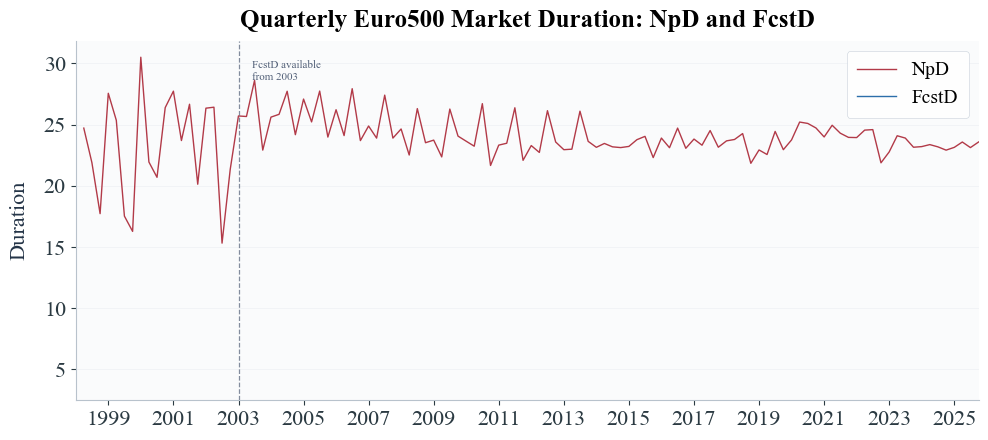

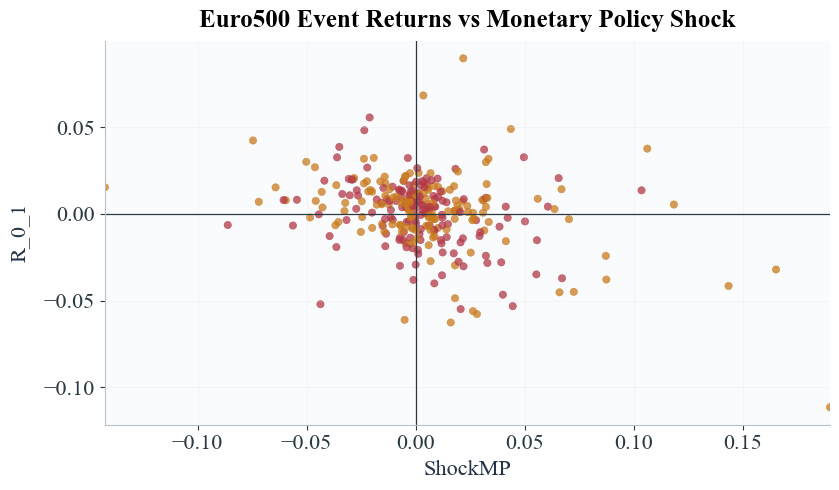

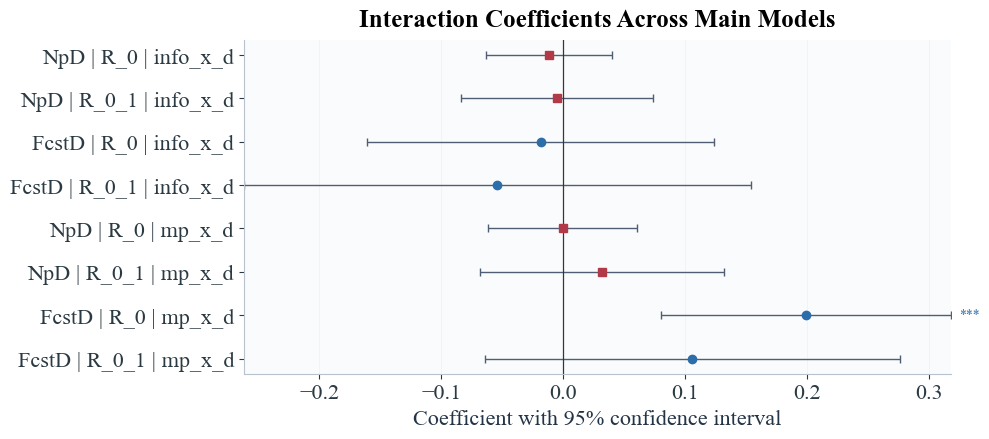

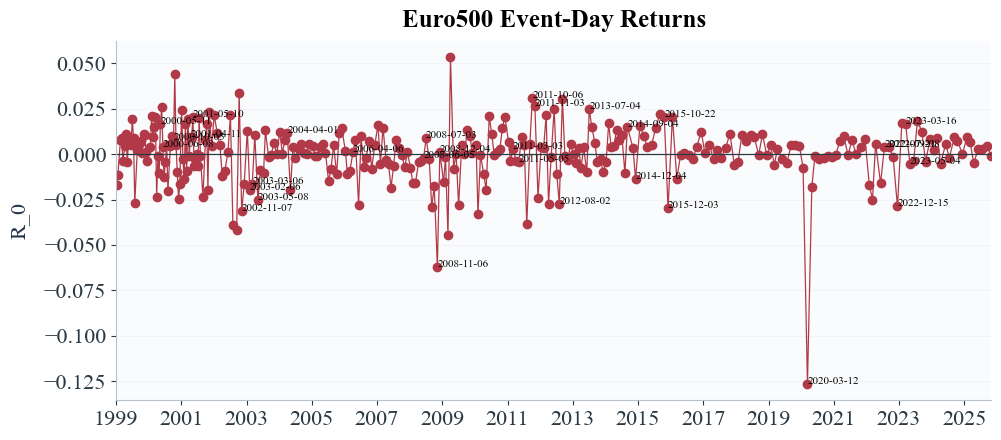

In [12]:
def coefficient_plot_data(results_df):
    subset = results_df[(results_df["model_label"] == "Model 1") & (results_df["duration_weighting"] == "value_weighted")].copy()
    subset = subset[subset["term"].isin(["mp_x_d", "info_x_d"])].copy()
    subset["label"] = subset["duration_variant"] + " | " + subset["return_window"] + " | " + subset["term"]
    subset["ci_low"] = subset["coef"] - 1.96 * subset["std_err"]
    subset["ci_high"] = subset["coef"] + 1.96 * subset["std_err"]
    _dur_order = {"NpD": 0, "FcstD": 1}
    subset["_dur_sort"] = subset["duration_variant"].map(_dur_order).fillna(99)
    return subset.sort_values(["term", "_dur_sort", "return_window"]).drop(columns=["_dur_sort"]).reset_index(drop=True)


# --- Duration color/marker conventions (consistent with firm-level notebook) ---
_DUR_COLORS = {
    "NpD":   COLORS["accent"],
    "FcstD": COLORS["blue"],
}
_DUR_MARKERS = {
    "NpD":   "s",
    "FcstD": "o",
}

# --- Time series plot: NpD (full history) and FcstD (from 2003) ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    market_duration_quarterly["quarter_end"],
    market_duration_quarterly["market_duration_netpayout"],
    label="NpD",
    color=_DUR_COLORS["NpD"],
)
ax.plot(
    market_duration_quarterly["quarter_end"],
    market_duration_quarterly["market_duration_fcstd"],
    label="FcstD",
    color=_DUR_COLORS["FcstD"],
)
# Vertical line at FcstD start
ax.axvline(pd.Timestamp("2003-01-01"), color=COLORS.get("neutral", "#888"),
           linewidth=0.9, linestyle="--", alpha=0.7)
ax.text(pd.Timestamp("2003-06-01"),
        ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 0,
        "FcstD available\nfrom 2003", fontsize=8, va="top",
        color=COLORS.get("neutral", "#888"))
ax.set_title("Quarterly Euro500 Market Duration: NpD and FcstD")
ax.set_xlabel("Quarter")
ax.set_ylabel("Duration")
style_axes(ax, grid_axis="y", grid_alpha=0.25)
style_time_axis(
    ax,
    x_min=market_duration_quarterly["quarter_end"].min(),
    x_max=market_duration_quarterly["quarter_end"].max(),
    x_ticks=market_duration_quarterly["quarter_end"],
    date_fmt="%Y",
)
style_legend(ax, loc="best")
fig.tight_layout()
save_figure(fig, "plot_market_duration_timeseries", dpi=200)
plt.show()

# --- Scatter plot: NpD as coloring variable ---
fig, ax = plt.subplots(figsize=(12, 4))
scatter_df = main_sample.dropna(subset=["ShockMP", "R_0_1", "market_duration_netpayout_z"]).copy()
colors = np.where(
    scatter_df["market_duration_netpayout_z"] >= scatter_df["market_duration_netpayout_z"].median(),
    _DUR_COLORS["NpD"],
    COLORS["orange"],
)
ax.scatter(scatter_df["ShockMP"], scatter_df["R_0_1"], c=colors, alpha=0.75, s=28)
ax.axhline(0, color=COLORS["reference"], linewidth=0.9)
ax.axvline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_title("Euro500 Event Returns vs Monetary Policy Shock")
ax.set_xlabel("ShockMP")
ax.set_ylabel("R_0_1")
style_axes(ax, grid_axis="both", grid_alpha=0.22)
fig.tight_layout()
save_figure(fig, "plot_scatter_shockmp_r01", dpi=200)
plt.show()

# --- Coefficient plot: NpD and FcstD interaction coefficients ---
coef_plot_df = coefficient_plot_data(results_main)
fig, ax = plt.subplots(figsize=(12, 4))
y_pos = np.arange(len(coef_plot_df))
coef_colors = [_DUR_COLORS.get(row["duration_variant"], COLORS.get("neutral", "#888")) for _, row in coef_plot_df.iterrows()]
coef_markers = [_DUR_MARKERS.get(row["duration_variant"], "o") for _, row in coef_plot_df.iterrows()]
for i, (_, row) in enumerate(coef_plot_df.iterrows()):
    ax.errorbar(
        row["coef"],
        i,
        xerr=1.96 * row["std_err"],
        fmt=coef_markers[i],
        color=coef_colors[i],
        ecolor=COLORS["neutral"],
        capsize=3,
    )
    # Significance stars — to the right of CI upper bound
    _star = significance_stars(row.get("p_value", np.nan))
    if _star:
        _ci_right = row["coef"] + 1.96 * row["std_err"]
        ax.text(_ci_right + abs(row["coef"]) * 0.03, i, _star,
                ha="left", va="center", fontsize=10,
                color=coef_colors[i])
ax.axvline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_plot_df["label"])
ax.invert_yaxis()
ax.set_title("Interaction Coefficients Across Main Models")
ax.set_xlabel("Coefficient with 95% confidence interval")
style_axes(ax, grid_axis="x", grid_alpha=0.25)
fig.tight_layout()
save_figure(fig, "plot_interaction_coefficients", dpi=200)
plt.show()

# --- Event returns over time ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(main_sample["event_date"], main_sample["R_0"], marker="o", linestyle="-", linewidth=0.9, color=COLORS["accent"])
shock_cutoff = main_sample["ShockMP"].abs().quantile(0.9)
for _, row in main_sample.iterrows():
    if abs(row["ShockMP"]) >= shock_cutoff:
        ax.annotate(row["event_date"].strftime("%Y-%m-%d"), (row["event_date"], row["R_0"]), fontsize=8)
ax.axhline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_title("Euro500 Event-Day Returns")
ax.set_xlabel("Event date")
ax.set_ylabel("R_0")
style_axes(ax, grid_axis="y", grid_alpha=0.25)
style_time_axis(
    ax,
    x_min=main_sample["event_date"].min(),
    x_max=main_sample["event_date"].max(),
    x_ticks=main_sample["event_date"],
    date_fmt="%Y",
)
fig.tight_layout()
save_figure(fig, "plot_event_returns_over_time", dpi=200)
plt.show()

## 12. Interpretation notes

This index-level exercise complements firm-level regressions by shifting the focus from cross-sectional heterogeneity to time variation in aggregate market exposure.

Key interpretation points:
- a negative `ShockMP × Duration` coefficient implies that tighter-than-expected ECB policy news hurts the index more when aggregate market duration is high
- a positive `ShockInfo × Duration` coefficient would be consistent with long-duration markets reacting more favorably to information shocks that improve expected growth or earnings prospects
- value-weighted market duration is the baseline because it measures the duration exposure of the market portfolio rather than the average firm
- the strict pre-event quarter matching prevents look-ahead bias and makes the timing assumption transparent


## 12A. Additional Identification Checks

The next sections strengthen the market-level duration analysis in three ways. First, quarterly market duration is expanded to monthly frequency to create more event-level variation. Second, the weak linear interaction design is complemented with a high-versus-low duration regime split. Third, the same baseline and regime specifications are re-estimated for large-shock subsamples where identification is strongest.


### Monthly Market Duration

Quarterly Euro500 duration is repeated to the three month-ends within the same calendar quarter. ECB events are then matched to the nearest previous month-end instead of the nearest previous quarter-end. This preserves the existing quarterly series while creating a denser event-level classification variable.


In [13]:
def build_monthly_market_duration(duration_df):
    monthly_rows = []
    for _, row in duration_df.sort_values("quarter_end").iterrows():
        quarter = row["quarter_end"].to_period("Q")
        months = pd.period_range(quarter.asfreq("M", how="start"), quarter.asfreq("M", how="end"), freq="M")
        for month in months:
            monthly_rows.append({
                "month_end": month.to_timestamp(how="end").normalize(),
                "quarter_end_source": row["quarter_end"],
                "market_duration_netpayout_monthly": row.get("market_duration_netpayout", np.nan),
                "market_duration_fcstd_monthly":     row.get("market_duration_fcstd", np.nan),
            })
    monthly = pd.DataFrame(monthly_rows).sort_values("month_end").drop_duplicates("month_end", keep="last").reset_index(drop=True)
    return monthly


def map_monthly_market_duration_to_events(events_df, monthly_duration_df):
    durations = monthly_duration_df.sort_values("month_end").copy()
    events = events_df.sort_values("event_date").copy()
    events["duration_lookup_date"] = events["event_date"] - pd.Timedelta(days=1)

    mapped = pd.merge_asof(
        events,
        durations,
        left_on="duration_lookup_date",
        right_on="month_end",
        direction="backward",
    )
    mapped = mapped.drop(columns=["duration_lookup_date"])
    mapped = mapped.rename(columns={
        "month_end": "matched_month",
        "market_duration_netpayout_monthly": "D_netpayout_monthly_event",
        "market_duration_fcstd_monthly":     "D_fcstd_monthly_event",
    })
    return mapped


market_duration_monthly = build_monthly_market_duration(market_duration_quarterly)
market_duration_netpayout_monthly = market_duration_monthly[["month_end", "market_duration_netpayout_monthly"]].copy()
market_duration_fcstd_monthly = market_duration_monthly[["month_end", "market_duration_fcstd_monthly"]].copy()
event_dataset_monthly = map_monthly_market_duration_to_events(event_dataset, market_duration_monthly)
D_netpayout_monthly_event = event_dataset_monthly["D_netpayout_monthly_event"].copy()
D_fcstd_monthly_event = event_dataset_monthly["D_fcstd_monthly_event"].copy()

monthly_mapping_diagnostics = event_dataset_monthly[[
    "event_date",
    "matched_quarter",
    "matched_month",
    "market_duration_fcstd",
    "market_duration_netpayout",
    "D_fcstd_monthly_event",
    "D_netpayout_monthly_event",
]].copy()

duration_variation_comparison = pd.DataFrame({
    "duration_measure": ["FcstD", "Net-Payout"],
    "quarterly_std": [
        market_duration_quarterly["market_duration_fcstd"].std(),
        market_duration_quarterly["market_duration_netpayout"].std(),
    ],
    "monthly_std": [
        market_duration_monthly["market_duration_fcstd_monthly"].std(),
        market_duration_monthly["market_duration_netpayout_monthly"].std(),
    ],
    "quarterly_unique_series": [
        market_duration_quarterly["market_duration_fcstd"].nunique(),
        market_duration_quarterly["market_duration_netpayout"].nunique(),
    ],
    "monthly_unique_series": [
        market_duration_monthly["market_duration_fcstd_monthly"].nunique(),
        market_duration_monthly["market_duration_netpayout_monthly"].nunique(),
    ],
    "quarterly_unique_event_values": [
        event_dataset_monthly["market_duration_fcstd"].nunique(),
        event_dataset_monthly["market_duration_netpayout"].nunique(),
    ],
    "monthly_unique_event_values": [
        event_dataset_monthly["D_fcstd_monthly_event"].nunique(),
        event_dataset_monthly["D_netpayout_monthly_event"].nunique(),
    ],
    "quarterly_unique_match_points": [
        event_dataset_monthly["matched_quarter"].nunique(),
        event_dataset_monthly["matched_quarter"].nunique(),
    ],
    "monthly_unique_match_points": [
        event_dataset_monthly["matched_month"].nunique(),
        event_dataset_monthly["matched_month"].nunique(),
    ],
})
duration_variation_comparison["event_variation_gain"] = duration_variation_comparison["monthly_unique_event_values"] - duration_variation_comparison["quarterly_unique_event_values"]
duration_variation_comparison["match_point_gain"] = duration_variation_comparison["monthly_unique_match_points"] - duration_variation_comparison["quarterly_unique_match_points"]
monthly_duration_correlation = market_duration_monthly[["market_duration_fcstd_monthly", "market_duration_netpayout_monthly"]].corr()

print("Monthly event mapping diagnostics:")
display_df(monthly_mapping_diagnostics, n=20)
print("Quarterly vs monthly duration diagnostics:")
display(duration_variation_comparison)
if (duration_variation_comparison["event_variation_gain"] <= 0).all():
    print("Distinct raw duration values stay tight in this sample, but monthly matching still increases the number of event match points.")
print("Correlation between monthly duration concepts:")
display(monthly_duration_correlation)

Monthly event mapping diagnostics:


,event_date,matched_quarter,matched_month,market_duration_fcstd,market_duration_netpayout,D_fcstd_monthly_event,D_netpayout_monthly_event
0,1999-01-07,1998-12-31,1998-12-31,NaN,27.561169,NaN,27.561169
1,1999-01-21,1998-12-31,1998-12-31,NaN,27.561169,NaN,27.561169
2,1999-02-18,1998-12-31,1999-01-31,NaN,27.561169,NaN,25.355315
3,1999-03-04,1998-12-31,1999-02-28,NaN,27.561169,NaN,25.355315
4,1999-03-18,1998-12-31,1999-02-28,NaN,27.561169,NaN,25.355315
5,1999-04-08,1999-03-31,1999-03-31,NaN,25.355315,NaN,25.355315
6,1999-04-22,1999-03-31,1999-03-31,NaN,25.355315,NaN,25.355315
7,1999-05-06,1999-03-31,1999-04-30,NaN,25.355315,NaN,17.525576
8,1999-05-20,1999-03-31,1999-04-30,NaN,25.355315,NaN,17.525576
9,1999-06-02,1999-03-31,1999-05-31,NaN,25.355315,NaN,17.525576


Quarterly vs monthly duration diagnostics:


,duration_measure,quarterly_std,monthly_std,quarterly_unique_series,monthly_unique_series,quarterly_unique_event_values,monthly_unique_event_values,quarterly_unique_match_points,monthly_unique_match_points,event_variation_gain,match_point_gain
0,FcstD,0.252978,0.249056,22,22,22,22,108,277,0,169
1,Net-Payout,2.231768,2.225036,111,111,108,108,108,277,0,169


Distinct raw duration values stay tight in this sample, but monthly matching still increases the number of event match points.
Correlation between monthly duration concepts:


,market_duration_fcstd_monthly,market_duration_netpayout_monthly
market_duration_fcstd_monthly,1.000000,0.495745
market_duration_netpayout_monthly,0.495745,1.000000


## FcstD Coverage Note
The analyst-based duration measure (FcstD) is available from Q4 2003
onward, limited by I/B/E/S CashEPS coverage for Euro Stoxx 500
constituents. FcstD regressions are therefore restricted to the
post-2003 subsample. The market-level FcstD is computed as a
value-weighted average across firms with usable FcstD estimates
(pv_fit_poor == False).


### High vs Low Duration Regimes

Instead of relying only on linear interactions, the sample is split at the median monthly market duration. This converts a weak slope-identification problem into a direct comparison of high-duration and low-duration market states.


In [14]:
analysis_sample = event_dataset_monthly.dropna(subset=[
    "ShockMP",
    "ShockInfo",
    "R_0_1",
    "D_netpayout_monthly_event",
]).copy()
analysis_sample["abs_ShockMP"] = analysis_sample["ShockMP"].abs()
analysis_sample["abs_ShockInfo"] = analysis_sample["ShockInfo"].abs()

# FcstD subsample for regime analysis
analysis_sample_fcstd = event_dataset_monthly.dropna(subset=[
    "ShockMP",
    "ShockInfo",
    "R_0_1",
    "D_fcstd_monthly_event",
    "D_netpayout_monthly_event",
]).copy()
analysis_sample_fcstd["abs_ShockMP"] = analysis_sample_fcstd["ShockMP"].abs()
analysis_sample_fcstd["abs_ShockInfo"] = analysis_sample_fcstd["ShockInfo"].abs()


def fit_baseline_market_regression(df, y_col="R_0_1", cov_type="HC1"):
    work = df[[y_col, "ShockMP", "ShockInfo"]].dropna().copy()
    X = sm.add_constant(work[["ShockMP", "ShockInfo"]], has_constant="add")
    y = work[y_col].astype(float)
    res = fit_ols(y, X.astype(float), cov_type=cov_type)
    return res, work


def run_baseline_market_table(sample_map, y_col="R_0_1"):
    rows = []
    for sample_label, sample_df in sample_map.items():
        res, work = fit_baseline_market_regression(sample_df, y_col=y_col, cov_type="HC1")
        rows.append({
            "sample": sample_label,
            "coef(ShockMP)": res.params.get("ShockMP", np.nan),
            "se(ShockMP)": res.bse.get("ShockMP", np.nan),
            "t(ShockMP)": res.tvalues.get("ShockMP", np.nan),
            "p(ShockMP)": res.pvalues.get("ShockMP", np.nan),
            "coef(ShockInfo)": res.params.get("ShockInfo", np.nan),
            "se(ShockInfo)": res.bse.get("ShockInfo", np.nan),
            "t(ShockInfo)": res.tvalues.get("ShockInfo", np.nan),
            "p(ShockInfo)": res.pvalues.get("ShockInfo", np.nan),
            "N": int(res.nobs),
            "R2": res.rsquared,
        })
    return pd.DataFrame(rows)


def run_duration_regime_table(df, duration_col, duration_label, sample_label="Full sample", y_col="R_0_1"):
    subset = df.dropna(subset=[duration_col, y_col, "ShockMP", "ShockInfo"]).copy()
    median_duration = subset[duration_col].median()
    subset["duration_regime"] = np.where(subset[duration_col] >= median_duration, "High", "Low")

    rows = []
    beta_store = {}
    for regime in ["High", "Low"]:
        part = subset[subset["duration_regime"] == regime].copy()
        res, work = fit_baseline_market_regression(part, y_col=y_col, cov_type="HC1")
        beta_store[regime] = res.params
        rows.append({
            "duration_measure": duration_label,
            "sample": sample_label,
            "regime": regime,
            "median_duration": median_duration,
            "coef(ShockMP)": res.params.get("ShockMP", np.nan),
            "se(ShockMP)": res.bse.get("ShockMP", np.nan),
            "t(ShockMP)": res.tvalues.get("ShockMP", np.nan),
            "p(ShockMP)": res.pvalues.get("ShockMP", np.nan),
            "coef(ShockInfo)": res.params.get("ShockInfo", np.nan),
            "se(ShockInfo)": res.bse.get("ShockInfo", np.nan),
            "t(ShockInfo)": res.tvalues.get("ShockInfo", np.nan),
            "p(ShockInfo)": res.pvalues.get("ShockInfo", np.nan),
            "N": int(res.nobs),
            "R2": res.rsquared,
        })

    delta_row = pd.DataFrame([{
        "duration_measure": duration_label,
        "sample": sample_label,
        "Delta_MP": beta_store.get("High", {}).get("ShockMP", np.nan) - beta_store.get("Low", {}).get("ShockMP", np.nan),
        "Delta_Info": beta_store.get("High", {}).get("ShockInfo", np.nan) - beta_store.get("Low", {}).get("ShockInfo", np.nan),
        "median_duration": median_duration,
        "N_total": len(subset),
    }])
    return pd.DataFrame(rows), delta_row


full_sample_map = {"Full sample": analysis_sample}
baseline_full_table = run_baseline_market_table(full_sample_map, y_col="R_0_1")

regime_netpayout_full, delta_netpayout_full = run_duration_regime_table(
    analysis_sample,
    duration_col="D_netpayout_monthly_event",
    duration_label="NpD",
    sample_label="Full sample",
)
regime_fcstd_full, delta_fcstd_full = run_duration_regime_table(
    analysis_sample_fcstd,
    duration_col="D_fcstd_monthly_event",
    duration_label="FcstD",
    sample_label="Full sample",
)

regime_results_full = pd.concat([regime_netpayout_full, regime_fcstd_full], ignore_index=True)
regime_differences_full = pd.concat([delta_netpayout_full, delta_fcstd_full], ignore_index=True)

print("Baseline regression on the full event sample (R_0_1):")
display(baseline_full_table)
print("Regime regressions with monthly market duration:")
display(regime_results_full)
print("High-minus-low coefficient differences:")
display(regime_differences_full)

Baseline regression on the full event sample (R_0_1):


,sample,coef(ShockMP),se(ShockMP),t(ShockMP),p(ShockMP),coef(ShockInfo),se(ShockInfo),t(ShockInfo),p(ShockInfo),N,R2
0,Full sample,-0.210608,0.047927,-4.39435,0.000011,0.248679,0.042453,5.857811,4.690082e-09,309,0.224161


Regime regressions with monthly market duration:


,duration_measure,sample,regime,median_duration,coef(ShockMP),se(ShockMP),t(ShockMP),p(ShockMP),coef(ShockInfo),se(ShockInfo),t(ShockInfo),p(ShockInfo),N,R2
0,NpD,Full sample,High,23.787056,-0.277129,0.060837,-4.555238,5.232626e-06,0.244908,0.045939,5.331151,9.759226e-08,155,0.360240
1,NpD,Full sample,Low,23.787056,-0.132063,0.064538,-2.046289,4.072795e-02,0.235793,0.063278,3.726315,1.942996e-04,154,0.128018
2,FcstD,Full sample,High,4.237434,-0.339523,0.056294,-6.031241,1.627054e-09,0.154067,0.087019,1.770500,7.664388e-02,27,0.607201
3,FcstD,Full sample,Low,4.237434,-0.400584,0.110479,-3.625872,2.879879e-04,-0.321492,0.185857,-1.729778,8.366989e-02,27,0.421182


High-minus-low coefficient differences:


,duration_measure,sample,Delta_MP,Delta_Info,median_duration,N_total
0,NpD,Full sample,-0.145066,0.009116,23.787056,309
1,FcstD,Full sample,0.061061,0.475559,4.237434,54


### Large Shock Subsample

Large shocks are defined as the top 30% of the absolute shock distribution. The baseline regression and the duration-regime split are then re-estimated separately for large monetary-policy shocks and large information shocks.


In [15]:
analysis_sample["large_MP"] = analysis_sample["abs_ShockMP"] >= analysis_sample["abs_ShockMP"].quantile(0.70)
analysis_sample["large_Info"] = analysis_sample["abs_ShockInfo"] >= analysis_sample["abs_ShockInfo"].quantile(0.70)
analysis_sample_fcstd["large_MP"] = analysis_sample_fcstd["abs_ShockMP"] >= analysis_sample_fcstd["abs_ShockMP"].quantile(0.70)
analysis_sample_fcstd["large_Info"] = analysis_sample_fcstd["abs_ShockInfo"] >= analysis_sample_fcstd["abs_ShockInfo"].quantile(0.70)

MP_large_sample = analysis_sample[analysis_sample["large_MP"]].copy()
Info_large_sample = analysis_sample[analysis_sample["large_Info"]].copy()
MP_large_sample_fcstd = analysis_sample_fcstd[analysis_sample_fcstd["large_MP"]].copy()
Info_large_sample_fcstd = analysis_sample_fcstd[analysis_sample_fcstd["large_Info"]].copy()

large_shock_sample_map = {
    "Full sample": analysis_sample,
    "MP_large_sample": MP_large_sample,
    "Info_large_sample": Info_large_sample,
}
baseline_large_shock_table = run_baseline_market_table(large_shock_sample_map, y_col="R_0_1")

regime_tables = []
delta_tables = []
for sample_label, sample_df in large_shock_sample_map.items():
    regime_netpayout_sample, delta_netpayout_sample = run_duration_regime_table(
        sample_df,
        duration_col="D_netpayout_monthly_event",
        duration_label="NpD",
        sample_label=sample_label,
    )
    regime_tables.append(regime_netpayout_sample)
    delta_tables.append(delta_netpayout_sample)

# FcstD regime tables on FcstD subsample
large_shock_sample_map_fcstd = {
    "Full sample": analysis_sample_fcstd,
    "MP_large_sample": MP_large_sample_fcstd,
    "Info_large_sample": Info_large_sample_fcstd,
}
for sample_label, sample_df in large_shock_sample_map_fcstd.items():
    regime_fcstd_sample, delta_fcstd_sample = run_duration_regime_table(
        sample_df,
        duration_col="D_fcstd_monthly_event",
        duration_label="FcstD",
        sample_label=sample_label,
    )
    regime_tables.append(regime_fcstd_sample)
    delta_tables.append(delta_fcstd_sample)

regime_results_large_shocks = pd.concat(regime_tables, ignore_index=True)
regime_differences_large_shocks = pd.concat(delta_tables, ignore_index=True)

print("Baseline comparison: full sample vs large-shock subsamples")
display(baseline_large_shock_table)
print("Regime comparison: high vs low duration across subsamples")
display(regime_results_large_shocks)
print("High-minus-low differences across subsamples")
display(regime_differences_large_shocks)

Baseline comparison: full sample vs large-shock subsamples


,sample,coef(ShockMP),se(ShockMP),t(ShockMP),p(ShockMP),coef(ShockInfo),se(ShockInfo),t(ShockInfo),p(ShockInfo),N,R2
0,Full sample,-0.210608,0.047927,-4.394350,0.000011,0.248679,0.042453,5.857811,4.690082e-09,309,0.224161
1,MP_large_sample,-0.199287,0.050780,-3.924550,0.000087,0.261332,0.062279,4.196114,2.715333e-05,93,0.347944
2,Info_large_sample,-0.234413,0.056522,-4.147295,0.000034,0.251053,0.045388,5.531239,3.179764e-08,93,0.394100


Regime comparison: high vs low duration across subsamples


,duration_measure,sample,regime,median_duration,coef(ShockMP),se(ShockMP),t(ShockMP),p(ShockMP),coef(ShockInfo),se(ShockInfo),t(ShockInfo),p(ShockInfo),N,R2
0,NpD,Full sample,High,23.787056,-0.277129,0.060837,-4.555238,5.232626e-06,0.244908,0.045939,5.331151,9.759226e-08,155,0.360240
1,NpD,Full sample,Low,23.787056,-0.132063,0.064538,-2.046289,4.072795e-02,0.235793,0.063278,3.726315,1.942996e-04,154,0.128018
2,NpD,MP_large_sample,High,23.700164,-0.273783,0.056977,-4.805110,1.546663e-06,0.251679,0.062938,3.998872,6.364507e-05,48,0.516523
3,NpD,MP_large_sample,Low,23.700164,-0.048337,0.060871,-0.794099,4.271377e-01,0.278593,0.085698,3.250878,1.150491e-03,45,0.248623
4,NpD,Info_large_sample,High,23.734276,-0.317119,0.059768,-5.305869,1.121374e-07,0.219416,0.047025,4.665970,3.071638e-06,49,0.579548
5,NpD,Info_large_sample,Low,23.734276,-0.076535,0.075580,-1.012642,3.112314e-01,0.262725,0.066772,3.934650,8.331812e-05,44,0.278046
6,FcstD,Full sample,High,4.237434,-0.339523,0.056294,-6.031241,1.627054e-09,0.154067,0.087019,1.770500,7.664388e-02,27,0.607201
7,FcstD,Full sample,Low,4.237434,-0.400584,0.110479,-3.625872,2.879879e-04,-0.321492,0.185857,-1.729778,8.366989e-02,27,0.421182
8,FcstD,MP_large_sample,High,4.191511,-0.384938,0.077912,-4.940651,7.786226e-07,0.220736,0.165230,1.335931,1.815718e-01,8,0.874072
9,FcstD,MP_large_sample,Low,4.191511,-0.320385,0.142738,-2.244562,2.479624e-02,-0.302425,0.352130,-0.858843,3.904271e-01,8,0.499439


High-minus-low differences across subsamples


,duration_measure,sample,Delta_MP,Delta_Info,median_duration,N_total
0,NpD,Full sample,-0.145066,0.009116,23.787056,309
1,NpD,MP_large_sample,-0.225445,-0.026914,23.700164,93
2,NpD,Info_large_sample,-0.240584,-0.043309,23.734276,93
3,FcstD,Full sample,0.061061,0.475559,4.237434,54
4,FcstD,MP_large_sample,-0.064553,0.523161,4.191511,16
5,FcstD,Info_large_sample,0.016233,0.409245,4.283287,16


### Additional Market-Level Plots

The charts below summarize the regime evidence directly. The first two compare high-duration and low-duration coefficients, while the scatter plot shows the raw relationship between event-matched market duration and the two-day Euro500 return window.


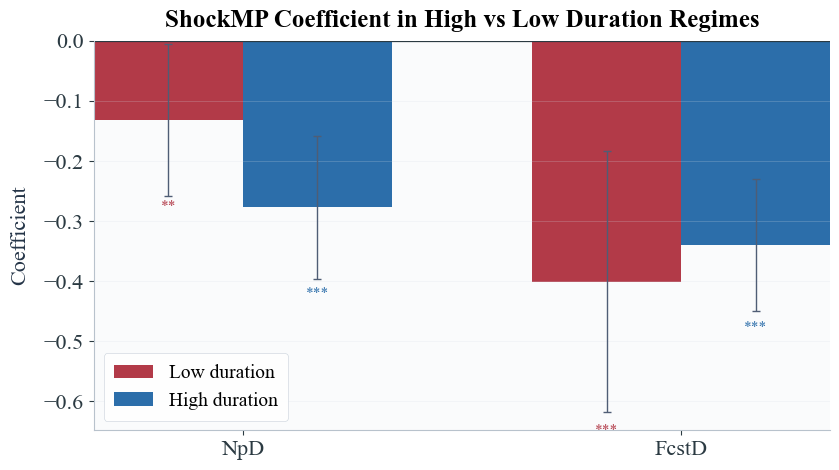

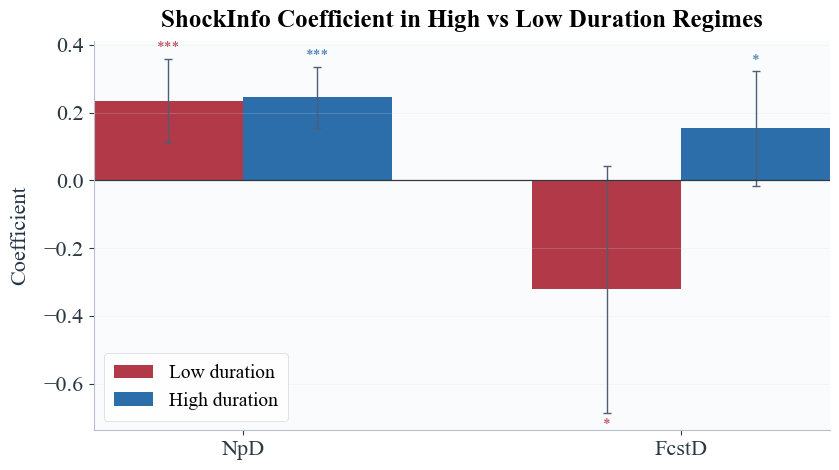

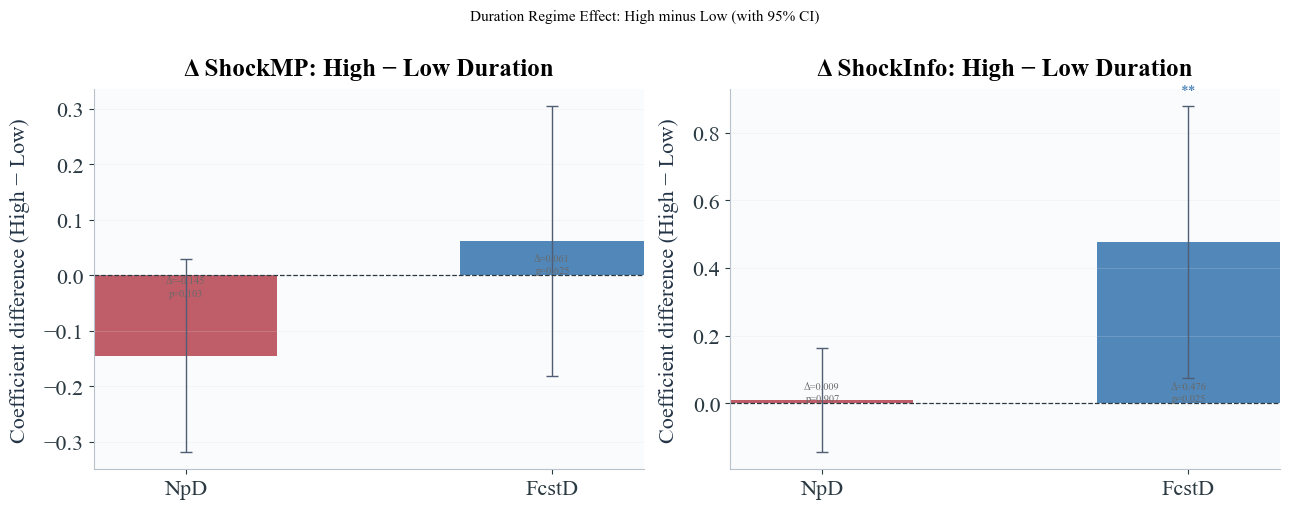

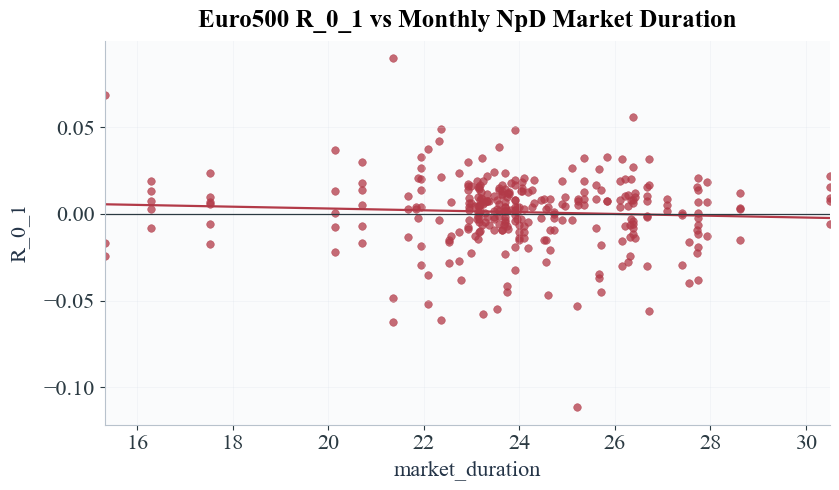

In [16]:
plot_regime_df = regime_results_full.copy()
duration_order = ["NpD", "FcstD"]
regime_order = ["Low", "High"]
x = np.arange(len(duration_order))
bar_width = 0.34

# --- ShockMP regime bars with CI and significance stars ---
fig, ax = plt.subplots(figsize=(12, 4))
for offset, regime in [(-bar_width / 2, "Low"), (bar_width / 2, "High")]:
    heights, errs, pvals = [], [], []
    for measure in duration_order:
        row = plot_regime_df.loc[
            (plot_regime_df["duration_measure"] == measure) &
            (plot_regime_df["regime"] == regime)]
        heights.append(float(row["coef(ShockMP)"].iloc[0]))
        errs.append(1.96 * float(row["se(ShockMP)"].iloc[0]))
        pvals.append(float(row["p(ShockMP)"].iloc[0]))
    _color = _DUR_COLORS.get(duration_order[0], COLORS["blue"]) if regime == "Low" else _DUR_COLORS.get(duration_order[1], COLORS["accent"])
    ax.bar(x + offset, heights, width=bar_width, label=f"{regime} duration",
           color=_color, yerr=errs, capsize=3,
           error_kw={"ecolor": COLORS.get("neutral", "#aaa"), "linewidth": 1.0})
    for ix, (h, p, e) in enumerate(zip(heights, pvals, errs)):
        _star = significance_stars(p)
        if _star and not np.isnan(h):
            _y_off = h + e + abs(h) * 0.05 if h >= 0 else h - e - abs(h) * 0.05
            ax.text(x[ix] + offset, _y_off, _star, ha="center",
                    va="bottom" if h >= 0 else "top", fontsize=11, color=_color)
ax.axhline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(duration_order)
ax.set_title("ShockMP Coefficient in High vs Low Duration Regimes")
ax.set_ylabel("Coefficient")
style_axes(ax, grid_axis="y", grid_alpha=0.22)
style_legend(ax, loc="best")
fig.tight_layout()
save_figure(fig, "plot_regime_shockmp_bars", dpi=200)
plt.show()

# --- ShockInfo regime bars with CI and significance stars ---
fig, ax = plt.subplots(figsize=(12, 4))
for offset, regime in [(-bar_width / 2, "Low"), (bar_width / 2, "High")]:
    heights, errs, pvals = [], [], []
    for measure in duration_order:
        row = plot_regime_df.loc[
            (plot_regime_df["duration_measure"] == measure) &
            (plot_regime_df["regime"] == regime)]
        heights.append(float(row["coef(ShockInfo)"].iloc[0]))
        errs.append(1.96 * float(row["se(ShockInfo)"].iloc[0]))
        pvals.append(float(row["p(ShockInfo)"].iloc[0]))
    _color = _DUR_COLORS.get(duration_order[0], COLORS["blue"]) if regime == "Low" else _DUR_COLORS.get(duration_order[1], COLORS["accent"])
    ax.bar(x + offset, heights, width=bar_width, label=f"{regime} duration",
           color=_color, yerr=errs, capsize=3,
           error_kw={"ecolor": COLORS.get("neutral", "#aaa"), "linewidth": 1.0})
    for ix, (h, p, e) in enumerate(zip(heights, pvals, errs)):
        _star = significance_stars(p)
        if _star and not np.isnan(h):
            _y_off = h + e + abs(h) * 0.05 if h >= 0 else h - e - abs(h) * 0.05
            ax.text(x[ix] + offset, _y_off, _star, ha="center",
                    va="bottom" if h >= 0 else "top", fontsize=11, color=_color)
ax.axhline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(duration_order)
ax.set_title("ShockInfo Coefficient in High vs Low Duration Regimes")
ax.set_ylabel("Coefficient")
style_axes(ax, grid_axis="y", grid_alpha=0.22)
style_legend(ax, loc="best")
fig.tight_layout()
save_figure(fig, "plot_regime_shockinfo_bars", dpi=200)
plt.show()

# --- Delta plot: High minus Low with CI and significance stars ---------------
from scipy import stats as scipy_stats

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, shock_label, coef_col, se_col in [
    (axes[0], "ShockMP",  "coef(ShockMP)",  "se(ShockMP)"),
    (axes[1], "ShockInfo", "coef(ShockInfo)", "se(ShockInfo)"),
]:
    deltas, delta_ses, delta_ps = [], [], []
    for measure in duration_order:
        row_h = plot_regime_df.loc[
            (plot_regime_df["duration_measure"] == measure) &
            (plot_regime_df["regime"] == "High")]
        row_l = plot_regime_df.loc[
            (plot_regime_df["duration_measure"] == measure) &
            (plot_regime_df["regime"] == "Low")]
        c_h  = float(row_h[coef_col].iloc[0])
        c_l  = float(row_l[coef_col].iloc[0])
        se_h = float(row_h[se_col].iloc[0])
        se_l = float(row_l[se_col].iloc[0])
        n_h  = int(row_h["N"].iloc[0])
        n_l  = int(row_l["N"].iloc[0])

        delta = c_h - c_l
        se_delta = np.sqrt(se_h**2 + se_l**2)
        t_delta = delta / se_delta if se_delta > 0 else np.nan
        p_delta = 2 * (1 - scipy_stats.t.cdf(abs(t_delta), df=max(n_h + n_l - 4, 1))) if not np.isnan(t_delta) else np.nan

        deltas.append(delta)
        delta_ses.append(se_delta)
        delta_ps.append(p_delta)

    x_d = np.arange(len(duration_order))
    errs_d = [1.96 * se for se in delta_ses]
    bar_colors = [_DUR_COLORS.get(d, COLORS["blue"]) for d in duration_order]

    ax.bar(x_d, deltas, width=0.5, color=bar_colors, alpha=0.82,
           yerr=errs_d, capsize=4,
           error_kw={"ecolor": COLORS.get("neutral", "#aaa"), "linewidth": 1.0})
    ax.axhline(0, color=COLORS["reference"], linewidth=0.9, linestyle="--")

    for ix, (d, p, e) in enumerate(zip(deltas, delta_ps, errs_d)):
        _star = significance_stars(p)
        if _star and not np.isnan(d):
            _y_off = d + e + abs(d) * 0.05 if d >= 0 else d - e - abs(d) * 0.05
            ax.text(ix, _y_off, _star, ha="center",
                    va="bottom" if d >= 0 else "top",
                    fontsize=11, color=bar_colors[ix])
        # Print delta and p below bar
        ax.text(ix, 0, f"Δ={d:.3f}\np={p:.3f}" if not np.isnan(p) else f"Δ={d:.3f}",
                ha="center", va="top" if d < 0 else "bottom",
                fontsize=7.5, color="dimgray", linespacing=1.3)

    ax.set_xticks(x_d)
    ax.set_xticklabels(duration_order)
    ax.set_title(f"Δ {shock_label}: High − Low Duration")
    ax.set_ylabel("Coefficient difference (High − Low)")
    style_axes(ax, grid_axis="y", grid_alpha=0.22)

fig.suptitle("Duration Regime Effect: High minus Low (with 95% CI)", fontsize=11, y=1.01)
fig.tight_layout()
save_figure(fig, "plot_regime_delta_with_ci", dpi=200)
plt.show()

# --- Scatter ---
scatter_duration_df = analysis_sample.dropna(subset=["D_netpayout_monthly_event", "R_0_1"]).copy()
x_vals = scatter_duration_df["D_netpayout_monthly_event"].to_numpy()
y_vals = scatter_duration_df["R_0_1"].to_numpy()
slope, intercept = np.polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(x_vals, y_vals, s=30, alpha=0.75, color=_DUR_COLORS["NpD"])
ax.plot(x_line, intercept + slope * x_line, color=COLORS["accent"], linewidth=1.6)
ax.axhline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_title("Euro500 R_0_1 vs Monthly NpD Market Duration")
ax.set_xlabel("market_duration")
ax.set_ylabel("R_0_1")
style_axes(ax, grid_axis="both", grid_alpha=0.22)
fig.tight_layout()
save_figure(fig, "plot_market_duration_scatter_r01", dpi=200)
plt.show()

### Interpretation of Market-Level Results

At the index level, linear interactions are naturally weak because aggregate market duration moves only gradually over time. Once firm-level heterogeneity is collapsed into a single market series, there is much less identifying variation than in the cross section, and the interaction term has to work with a relatively small number of event dates.

The regime split is more robust because it asks a simpler question: does the Euro500 react differently when the market is in a high-duration state versus a low-duration state? That comparison is less sensitive to small measurement error in the level of duration and easier to interpret economically than a continuous slope estimate.

Aggregation also reduces cross-sectional variation. At the firm level, duration differs strongly across companies and sectors; at the market level, those differences are averaged into one portfolio exposure. As a result, market-level duration effects are difficult to detect due to limited time variation and aggregation, but regime-based evidence may still reveal economically meaningful differences.

Taken together, the notebook should answer three questions. First, the Euro500 does react to ECB monetary-policy and information shocks. Second, market duration may matter, but the evidence is clearer in discrete high-versus-low duration states than in linear interactions. Third, the effect is most informative when attention is restricted to large shocks, where the signal-to-noise ratio is stronger.


### Robustness 1: First Differences of Market Duration

We test whether changes in aggregate market duration, rather than its level, drive cross-event variation in index return sensitivity. First-differencing removes any slow-moving trend in market duration and provides a cleaner identification in a time-series context.


In [17]:
# ── Robustness 1: First differences of NpD market duration ────────────────

# Quarter-over-quarter change in NpD
market_duration_quarterly = market_duration_quarterly.sort_values("quarter_end").reset_index(drop=True)
market_duration_quarterly["delta_npd"] = market_duration_quarterly["market_duration_netpayout"].diff()
market_duration_quarterly["delta_npd_z"] = standardize_series(market_duration_quarterly["delta_npd"])

# Build monthly interpolation for delta_npd
_delta_monthly_rows = []
for _, row in market_duration_quarterly.sort_values("quarter_end").iterrows():
    quarter = row["quarter_end"].to_period("Q")
    months = pd.period_range(quarter.asfreq("M", how="start"), quarter.asfreq("M", how="end"), freq="M")
    for month in months:
        _delta_monthly_rows.append({
            "month_end": month.to_timestamp(how="end").normalize(),
            "delta_npd_monthly": row.get("delta_npd", np.nan),
            "delta_npd_z_monthly": row.get("delta_npd_z", np.nan),
        })
_delta_monthly = pd.DataFrame(_delta_monthly_rows).sort_values("month_end").drop_duplicates("month_end", keep="last").reset_index(drop=True)

# Map delta to events via as-of merge
_events_for_delta = event_dataset_monthly.sort_values("event_date").copy()
_events_for_delta["_lookup"] = _events_for_delta["event_date"] - pd.Timedelta(days=1)
_events_for_delta = pd.merge_asof(
    _events_for_delta,
    _delta_monthly.sort_values("month_end"),
    left_on="_lookup",
    right_on="month_end",
    direction="backward",
)
_events_for_delta = _events_for_delta.drop(columns=["_lookup", "month_end"], errors="ignore")

# Build analysis sample for first-diff regressions
_fd_sample = _events_for_delta.dropna(subset=[
    "ShockMP", "ShockInfo", "R_0", "R_0_1", "delta_npd_z_monthly"
]).copy()
print(f"First-difference sample: {len(_fd_sample):,} events")

# Run Model 1 (no year FE) and Model 2 (year FE) for R_0 and R_0_1
_fd_rows = []
for return_window in ["R_0", "R_0_1"]:
    for calendar_controls, model_label in [(False, "Model 1"), (True, "Model 2")]:
        work, X, y = build_design_matrix(
            _fd_sample, y_col=return_window,
            duration_col="delta_npd_z_monthly",
            include_both_shocks=True,
            calendar_controls=calendar_controls,
        )
        res = fit_ols(y, X, cov_type="HC1")
        _fd_rows.append({
            "model": model_label,
            "return_window": return_window,
            "duration_col": "ΔNpD (z-scored)",
            "coef(ShockMP×ΔD)": res.params.get("mp_x_d", np.nan),
            "t(ShockMP×ΔD)": res.tvalues.get("mp_x_d", np.nan),
            "p(ShockMP×ΔD)": res.pvalues.get("mp_x_d", np.nan),
            "coef(ShockInfo×ΔD)": res.params.get("info_x_d", np.nan),
            "t(ShockInfo×ΔD)": res.tvalues.get("info_x_d", np.nan),
            "p(ShockInfo×ΔD)": res.pvalues.get("info_x_d", np.nan),
            "N": int(res.nobs),
            "R2": res.rsquared,
        })

rob1_first_diff = pd.DataFrame(_fd_rows)
rob1_first_diff.to_csv(output_dir / "index_robustness_first_differences.csv", index=False)

print("Robustness 1: First differences of market duration")
display(rob1_first_diff)

First-difference sample: 309 events
Robustness 1: First differences of market duration


,model,return_window,duration_col,coef(ShockMP×ΔD),t(ShockMP×ΔD),p(ShockMP×ΔD),coef(ShockInfo×ΔD),t(ShockInfo×ΔD),p(ShockInfo×ΔD),N,R2
0,Model 1,R_0,ΔNpD (z-scored),-0.057454,-1.541532,0.123187,0.015800,0.741603,0.458328,309,0.343676
1,Model 2,R_0,ΔNpD (z-scored),-0.055950,-1.552194,0.120616,0.024878,1.046039,0.295543,309,0.404044
2,Model 1,R_0_1,ΔNpD (z-scored),-0.102382,-1.927332,0.053938,0.030351,0.839007,0.401465,309,0.243541
3,Model 2,R_0_1,ΔNpD (z-scored),-0.116738,-2.203303,0.027573,0.047065,1.185489,0.235824,309,0.311886


### Robustness 2: Rolling 5-Year Window Regime Regression

To assess the temporal stability of the duration regime effect, we estimate the High-minus-Low coefficient difference in rolling 5-year windows. Structural breaks around the GFC (2008) and the onset of unconventional monetary policy (2015) are highlighted.


Rolling regime results: 56 windows


,duration_measure,sample,Delta_MP,Delta_Info,median_duration,N_total,window_end,n_events
0,NpD,Rolling 1999-12-02,-0.959576,0.393552,17.525576,21,1999-12-02,21
1,NpD,Rolling 1999-12-15,-1.160081,0.228939,21.440446,22,1999-12-15,22
2,NpD,Rolling 2000-06-08,-0.566709,0.050071,21.946028,33,2000-06-08,33
3,NpD,Rolling 2000-06-21,-0.569663,0.049639,21.946028,34,2000-06-21,34
4,NpD,Rolling 2000-12-14,-0.457935,0.118822,21.946028,45,2000-12-14,45
5,NpD,Rolling 2001-06-07,-0.182528,0.150618,23.700164,57,2001-06-07,57
6,NpD,Rolling 2001-06-21,-0.181737,0.152644,23.700164,58,2001-06-21,58
7,NpD,Rolling 2001-12-06,-0.201135,0.167522,23.700164,67,2001-12-06,67
8,NpD,Rolling 2002-06-06,-0.155899,0.162627,23.700164,73,2002-06-06,73
9,NpD,Rolling 2002-12-05,-0.179221,0.090026,23.700164,79,2002-12-05,79


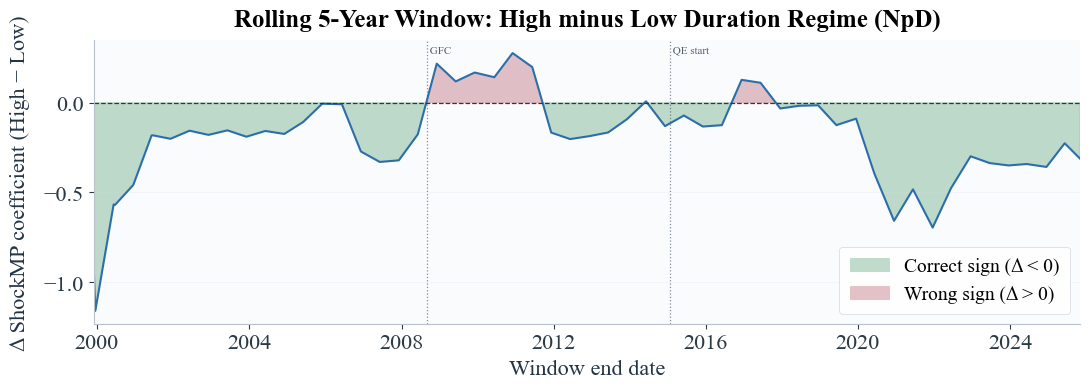

In [18]:
# ── Robustness 2: Rolling 5-year window regime regression ─────────────────

window_months = 60
step_months = 6

rolling_rows = []
dates = sorted(analysis_sample["event_date"].unique())

for end_date in dates:
    start_date = end_date - pd.DateOffset(months=window_months)
    window_df = analysis_sample[
        (analysis_sample["event_date"] >= start_date) &
        (analysis_sample["event_date"] <= end_date)
    ].copy()

    if window_df["D_netpayout_monthly_event"].notna().sum() < 20:
        continue

    _, delta_row = run_duration_regime_table(
        window_df,
        duration_col="D_netpayout_monthly_event",
        duration_label="NpD",
        sample_label=f"Rolling {str(end_date)[:10]}",
    )
    delta_row["window_end"] = end_date
    delta_row["n_events"] = len(window_df)
    rolling_rows.append(delta_row)

rolling_results = pd.concat(rolling_rows, ignore_index=True)

# Keep only semi-annual window ends to reduce overlap
rolling_results = rolling_results[
    rolling_results["window_end"].dt.month.isin([6, 12])
    | (rolling_results["window_end"] == rolling_results["window_end"].max())
].copy().reset_index(drop=True)

rolling_results.to_csv(output_dir / "index_robustness_rolling_regime.csv", index=False)

print(f"Rolling regime results: {len(rolling_results)} windows")
display(rolling_results)

# ── Plot ──
fig, ax = plt.subplots(figsize=(12, 4))
x_dates = rolling_results["window_end"]
y_delta = rolling_results["Delta_MP"].astype(float)

ax.fill_between(
    x_dates, 0, y_delta,
    where=(y_delta <= 0), interpolate=True,
    color=COLORS.get("green", "#2ca02c"), alpha=0.3, label="Correct sign (Δ < 0)",
)
ax.fill_between(
    x_dates, 0, y_delta,
    where=(y_delta > 0), interpolate=True,
    color=COLORS.get("red", "#d62728"), alpha=0.3, label="Wrong sign (Δ > 0)",
)
ax.plot(x_dates, y_delta, color=COLORS.get("blue", "#1f77b4"), linewidth=1.5)
ax.axhline(0, color=COLORS["reference"], linewidth=0.9, linestyle="--")

# Structural break markers
for event_date, label in [(pd.Timestamp("2008-09-01"), "GFC"),
                           (pd.Timestamp("2015-01-22"), "QE start")]:
    if x_dates.min() <= event_date <= x_dates.max():
        ax.axvline(event_date, color=COLORS.get("neutral", "#888"),
                   linewidth=0.9, linestyle=":", alpha=0.7)
        ax.text(event_date, ax.get_ylim()[1] * 0.92, f" {label}",
                fontsize=8, va="top", color=COLORS.get("neutral", "#888"))

ax.set_title("Rolling 5-Year Window: High minus Low Duration Regime (NpD)")
ax.set_xlabel("Window end date")
ax.set_ylabel("Δ ShockMP coefficient (High − Low)")
style_axes(ax, grid_axis="y", grid_alpha=0.22)
style_legend(ax, loc="best")
fig.tight_layout()
save_figure(fig, "plot_rolling_regime_delta", dpi=200)
plt.show()

### Robustness 3: Alternative Regime Thresholds (P33/P67 and P25/P75)

The median split into High- and Low-duration regimes is arbitrary. We verify that the direction and approximate magnitude of the regime difference is stable across alternative threshold choices (P33/P67, P25/P75).


Robustness 3: Alternative regime thresholds


,threshold,duration_measure,regime,coef_ShockMP,se_ShockMP,t_ShockMP,p_ShockMP,N
0,P50/P50,NpD,High,-0.277129,0.060837,-4.555238,0.000005,155
1,P50/P50,NpD,Low,-0.132063,0.064538,-2.046289,0.040728,154
2,P50/P50,NpD,Delta (High - Low),-0.145066,0.088692,-1.635617,0.102951,309
3,P33/P67,NpD,High,-0.321181,0.067073,-4.788499,0.000002,103
4,P33/P67,NpD,Low,-0.065177,0.063671,-1.023653,0.305999,103
5,P33/P67,NpD,Delta (High - Low),-0.256004,0.092482,-2.768157,0.006162,206
6,P25/P75,NpD,High,-0.241066,0.063171,-3.816093,0.000136,79
7,P25/P75,NpD,Low,-0.078279,0.068798,-1.137823,0.255194,79
8,P25/P75,NpD,Delta (High - Low),-0.162787,0.093401,-1.742886,0.083350,158


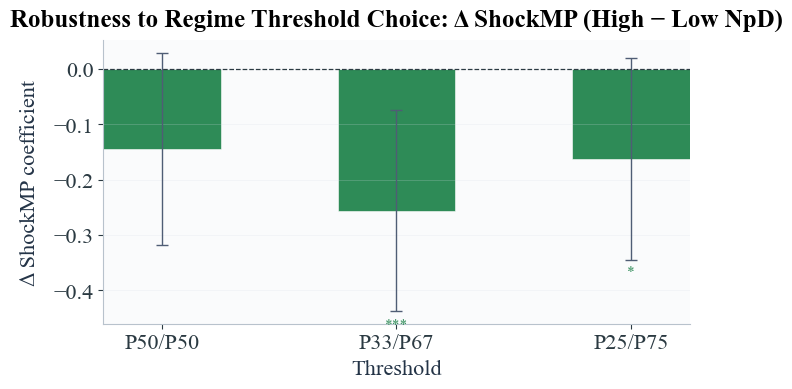

In [19]:
# ── Robustness 3: Alternative regime thresholds ──────────────────────────

def run_regime_threshold(df, duration_col, duration_label,
                         lo_q, hi_q, y_col="R_0_1"):
    subset = df.dropna(
        subset=[duration_col, y_col, "ShockMP", "ShockInfo"]).copy()
    lo_val = subset[duration_col].quantile(lo_q)
    hi_val = subset[duration_col].quantile(hi_q)
    # Only keep observations in bottom lo_q or top (1-hi_q) — drop middle
    mask = (subset[duration_col] <= lo_val) | (subset[duration_col] >= hi_val)
    subset = subset[mask].copy()
    subset["regime"] = np.where(
        subset[duration_col] >= hi_val, "High", "Low")

    rows = []
    beta_store = {}
    se_store = {}
    for regime in ["High", "Low"]:
        part = subset[subset["regime"] == regime].copy()
        res, _ = fit_baseline_market_regression(
            part, y_col=y_col, cov_type="HC1")
        beta_store[regime] = res.params
        se_store[regime] = res.bse
        rows.append({
            "threshold": f"P{int(lo_q*100)}/P{int(hi_q*100)}",
            "duration_measure": duration_label,
            "regime": regime,
            "coef_ShockMP": res.params.get("ShockMP", np.nan),
            "se_ShockMP": res.bse.get("ShockMP", np.nan),
            "t_ShockMP": res.tvalues.get("ShockMP", np.nan),
            "p_ShockMP": res.pvalues.get("ShockMP", np.nan),
            "N": int(res.nobs),
        })
    delta = (beta_store.get("High", {}).get("ShockMP", np.nan) -
             beta_store.get("Low",  {}).get("ShockMP", np.nan))
    # SE for delta via sqrt(se_high^2 + se_low^2) (independent samples)
    se_high = se_store.get("High", {}).get("ShockMP", np.nan)
    se_low = se_store.get("Low", {}).get("ShockMP", np.nan)
    se_delta = np.sqrt(se_high**2 + se_low**2) if not (np.isnan(se_high) or np.isnan(se_low)) else np.nan
    t_delta = delta / se_delta if se_delta and not np.isnan(se_delta) and se_delta > 0 else np.nan
    from scipy import stats as scipy_stats
    n_total = len(subset)
    p_delta = 2 * (1 - scipy_stats.t.cdf(abs(t_delta), df=max(n_total - 4, 1))) if not np.isnan(t_delta) else np.nan
    rows.append({
        "threshold": f"P{int(lo_q*100)}/P{int(hi_q*100)}",
        "duration_measure": duration_label,
        "regime": "Delta (High - Low)",
        "coef_ShockMP": delta,
        "se_ShockMP": se_delta,
        "t_ShockMP": t_delta,
        "p_ShockMP": p_delta,
        "N": n_total,
    })
    return pd.DataFrame(rows)


threshold_results = pd.concat([
    run_regime_threshold(analysis_sample, "D_netpayout_monthly_event",
                         "NpD", 0.50, 0.50, y_col="R_0_1"),
    run_regime_threshold(analysis_sample, "D_netpayout_monthly_event",
                         "NpD", 0.33, 0.67, y_col="R_0_1"),
    run_regime_threshold(analysis_sample, "D_netpayout_monthly_event",
                         "NpD", 0.25, 0.75, y_col="R_0_1"),
], ignore_index=True)

threshold_results.to_csv(output_dir / "index_robustness_thresholds.csv", index=False)

print("Robustness 3: Alternative regime thresholds")
display(threshold_results)

# ── Plot ──
delta_rows = threshold_results[threshold_results["regime"] == "Delta (High - Low)"].copy()
x_labels = delta_rows["threshold"].tolist()
y_vals = delta_rows["coef_ShockMP"].astype(float).tolist()
y_errs = [1.96 * float(se) if not np.isnan(se) else 0.0 for se in delta_rows["se_ShockMP"]]
p_vals = delta_rows["p_ShockMP"].astype(float).tolist()
bar_colors = [COLORS.get("green", "#2ca02c") if v <= 0 else COLORS.get("red", "#d62728") for v in y_vals]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(x_labels, y_vals, color=bar_colors, width=0.5, edgecolor="white",
              yerr=y_errs, capsize=4,
              error_kw={"ecolor": COLORS.get("neutral", "#aaa"), "linewidth": 1.0})
for ix, (v, p, e) in enumerate(zip(y_vals, p_vals, y_errs)):
    _star = significance_stars(p)
    if _star and not np.isnan(v):
        _y_off = v + e + abs(v) * 0.05 if v >= 0 else v - e - abs(v) * 0.05
        ax.text(ix, _y_off, _star, ha="center",
                va="bottom" if v >= 0 else "top", fontsize=11,
                color=bar_colors[ix])
ax.axhline(0, color=COLORS["reference"], linewidth=0.9, linestyle="--")
ax.set_title("Robustness to Regime Threshold Choice: Δ ShockMP (High − Low NpD)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Δ ShockMP coefficient")
style_axes(ax, grid_axis="y", grid_alpha=0.22)
fig.tight_layout()
save_figure(fig, "plot_threshold_robustness", dpi=200)
plt.show()

### Robustness 4: Lagged Market Duration

To address the mild simultaneity concern arising from using the contemporaneous quarter's market duration, we replace it with the lagged duration from the previous quarter. This ensures the regressor is strictly predetermined relative to the event return.


In [20]:
# ── Robustness 4: Lagged market duration ─────────────────────────────────

# Shift quarterly NpD back by one quarter
market_duration_quarterly["npd_lag1"] = (
    market_duration_quarterly["market_duration_netpayout"].shift(1))
market_duration_quarterly["npd_lag1_z"] = standardize_series(
    market_duration_quarterly["npd_lag1"])

# Build monthly interpolation for lagged NpD
_lag_monthly_rows = []
for _, row in market_duration_quarterly.sort_values("quarter_end").iterrows():
    quarter = row["quarter_end"].to_period("Q")
    months = pd.period_range(quarter.asfreq("M", how="start"), quarter.asfreq("M", how="end"), freq="M")
    for month in months:
        _lag_monthly_rows.append({
            "month_end": month.to_timestamp(how="end").normalize(),
            "npd_lag1_monthly": row.get("npd_lag1", np.nan),
            "npd_lag1_z_monthly": row.get("npd_lag1_z", np.nan),
        })
_lag_monthly = pd.DataFrame(_lag_monthly_rows).sort_values("month_end").drop_duplicates("month_end", keep="last").reset_index(drop=True)

# Map lagged duration to events
_events_for_lag = event_dataset_monthly.sort_values("event_date").copy()
_events_for_lag["_lookup"] = _events_for_lag["event_date"] - pd.Timedelta(days=1)
_events_for_lag = pd.merge_asof(
    _events_for_lag,
    _lag_monthly.sort_values("month_end"),
    left_on="_lookup",
    right_on="month_end",
    direction="backward",
)
_events_for_lag = _events_for_lag.drop(columns=["_lookup", "month_end"], errors="ignore")

# Build lagged sample
_lag_sample = _events_for_lag.dropna(subset=[
    "ShockMP", "ShockInfo", "R_0", "R_0_1", "npd_lag1_z_monthly"
]).copy()
print(f"Lagged duration sample: {len(_lag_sample):,} events")

# Run Model 1 and Model 2 with lagged duration
_lag_rows = []
for return_window in ["R_0", "R_0_1"]:
    for calendar_controls, model_label in [(False, "Model 1"), (True, "Model 2")]:
        # Lagged
        work, X, y = build_design_matrix(
            _lag_sample, y_col=return_window,
            duration_col="npd_lag1_z_monthly",
            include_both_shocks=True,
            calendar_controls=calendar_controls,
        )
        res_lag = fit_ols(y, X, cov_type="HC1")

        # Levels (contemporaneous) for comparison — from analysis_sample
        _lev_sub = analysis_sample.dropna(
            subset=[return_window, "D_netpayout_monthly_event", "ShockMP", "ShockInfo"]).copy()
        # Standardize the levels column for comparability
        _lev_sub["D_npd_z"] = standardize_series(_lev_sub["D_netpayout_monthly_event"])
        work_l, X_l, y_l = build_design_matrix(
            _lev_sub, y_col=return_window,
            duration_col="D_npd_z",
            include_both_shocks=True,
            calendar_controls=calendar_controls,
        )
        res_lev = fit_ols(y_l, X_l, cov_type="HC1")

        _lag_rows.append({
            "model": model_label,
            "return_window": return_window,
            "variant": "Levels (NpD)",
            "coef(ShockMP×D)": res_lev.params.get("mp_x_d", np.nan),
            "t(ShockMP×D)": res_lev.tvalues.get("mp_x_d", np.nan),
            "p(ShockMP×D)": res_lev.pvalues.get("mp_x_d", np.nan),
            "N": int(res_lev.nobs),
        })
        _lag_rows.append({
            "model": model_label,
            "return_window": return_window,
            "variant": "Lagged (NpD t-1)",
            "coef(ShockMP×D)": res_lag.params.get("mp_x_d", np.nan),
            "t(ShockMP×D)": res_lag.tvalues.get("mp_x_d", np.nan),
            "p(ShockMP×D)": res_lag.pvalues.get("mp_x_d", np.nan),
            "N": int(res_lag.nobs),
        })

rob4_lagged = pd.DataFrame(_lag_rows)
rob4_lagged.to_csv(output_dir / "index_robustness_lagged_duration.csv", index=False)

print("Robustness 4: Levels vs lagged market duration")
display(rob4_lagged)

Lagged duration sample: 309 events
Robustness 4: Levels vs lagged market duration


,model,return_window,variant,coef(ShockMP×D),t(ShockMP×D),p(ShockMP×D),N
0,Model 1,R_0,Levels (NpD),-0.057926,-1.303931,0.192257,309
1,Model 1,R_0,Lagged (NpD t-1),0.029623,0.865929,0.386529,309
2,Model 2,R_0,Levels (NpD),-0.066990,-1.693629,0.090336,309
3,Model 2,R_0,Lagged (NpD t-1),0.023160,0.678066,0.497730,309
4,Model 1,R_0_1,Levels (NpD),-0.087177,-1.722088,0.085054,309
5,Model 1,R_0_1,Lagged (NpD t-1),0.067824,1.150119,0.250095,309
6,Model 2,R_0_1,Levels (NpD),-0.115018,-2.556034,0.010587,309
7,Model 2,R_0_1,Lagged (NpD t-1),0.070980,1.239518,0.215154,309


### Robustness Summary

The table below consolidates the key result from each robustness check into a single compact view.


In [21]:
# ── Robustness summary across all four checks ────────────────────────────

_summary_rows = []

# Rob 1: First differences — Model 1, R_0_1
_r1 = rob1_first_diff[(rob1_first_diff["model"] == "Model 1") & (rob1_first_diff["return_window"] == "R_0_1")]
if len(_r1):
    _r1 = _r1.iloc[0]
    _summary_rows.append({
        "Check": "First differences (ΔNpD)",
        "Duration": "ΔNpD (z)",
        "Return": "R_0_1",
        "N": _r1["N"],
        "coef(ShockMP×D)": _r1["coef(ShockMP×ΔD)"],
        "t-stat": _r1["t(ShockMP×ΔD)"],
        "Sign correct?": _r1["coef(ShockMP×ΔD)"] < 0,
    })

# Rob 2: Rolling regime — overall median Delta_MP
if len(rolling_results):
    _r2_median = rolling_results["Delta_MP"].astype(float).median()
    _summary_rows.append({
        "Check": "Rolling 5yr regime (median Δ)",
        "Duration": "NpD regime",
        "Return": "R_0_1",
        "N": int(rolling_results["n_events"].median()),
        "coef(ShockMP×D)": _r2_median,
        "t-stat": np.nan,
        "Sign correct?": _r2_median < 0,
    })

# Rob 3: Threshold — P50 delta
_r3 = threshold_results[
    (threshold_results["threshold"] == "P50/P50") &
    (threshold_results["regime"] == "Delta (High - Low)")
]
if len(_r3):
    _r3 = _r3.iloc[0]
    _summary_rows.append({
        "Check": "Regime P50 (median)",
        "Duration": "NpD regime",
        "Return": "R_0_1",
        "N": _r3["N"],
        "coef(ShockMP×D)": _r3["coef_ShockMP"],
        "t-stat": np.nan,
        "Sign correct?": _r3["coef_ShockMP"] < 0,
    })
_r3b = threshold_results[
    (threshold_results["threshold"] == "P33/P67") &
    (threshold_results["regime"] == "Delta (High - Low)")
]
if len(_r3b):
    _r3b = _r3b.iloc[0]
    _summary_rows.append({
        "Check": "Regime P33/P67",
        "Duration": "NpD regime",
        "Return": "R_0_1",
        "N": _r3b["N"],
        "coef(ShockMP×D)": _r3b["coef_ShockMP"],
        "t-stat": np.nan,
        "Sign correct?": _r3b["coef_ShockMP"] < 0,
    })
_r3c = threshold_results[
    (threshold_results["threshold"] == "P25/P75") &
    (threshold_results["regime"] == "Delta (High - Low)")
]
if len(_r3c):
    _r3c = _r3c.iloc[0]
    _summary_rows.append({
        "Check": "Regime P25/P75",
        "Duration": "NpD regime",
        "Return": "R_0_1",
        "N": _r3c["N"],
        "coef(ShockMP×D)": _r3c["coef_ShockMP"],
        "t-stat": np.nan,
        "Sign correct?": _r3c["coef_ShockMP"] < 0,
    })

# Rob 4: Lagged duration — Model 1, R_0_1
_r4 = rob4_lagged[
    (rob4_lagged["model"] == "Model 1") &
    (rob4_lagged["return_window"] == "R_0_1") &
    (rob4_lagged["variant"] == "Lagged (NpD t-1)")
]
if len(_r4):
    _r4 = _r4.iloc[0]
    _summary_rows.append({
        "Check": "Lagged NpD (t−1)",
        "Duration": "NpD lag1 (z)",
        "Return": "R_0_1",
        "N": _r4["N"],
        "coef(ShockMP×D)": _r4["coef(ShockMP×D)"],
        "t-stat": _r4["t(ShockMP×D)"],
        "Sign correct?": _r4["coef(ShockMP×D)"] < 0,
    })

rob_summary = pd.DataFrame(_summary_rows)
rob_summary.to_csv(output_dir / "index_robustness_summary.csv", index=False)

print("Robustness summary across all four checks:")
display(rob_summary)

Robustness summary across all four checks:


,Check,Duration,Return,N,coef(ShockMP×D),t-stat,Sign correct?
0,First differences (ΔNpD),ΔNpD (z),R_0_1,309,-0.102382,-1.927332,True
1,Rolling 5yr regime (median Δ),NpD regime,R_0_1,58,-0.175290,NaN,True
2,Regime P50 (median),NpD regime,R_0_1,309,-0.145066,NaN,True
3,Regime P33/P67,NpD regime,R_0_1,206,-0.256004,NaN,True
4,Regime P25/P75,NpD regime,R_0_1,158,-0.162787,NaN,True
5,Lagged NpD (t−1),NpD lag1 (z),R_0_1,309,0.067824,1.150119,False


### Extension A: Subperiod Analysis

We split the full sample at three structural break dates to test whether the
aggregate market's ECB-shock sensitivity, and its dependence on market duration,
is stable over time or concentrated in a particular regime.

The three cuts are:
- **Pre/Post GFC**: September 2008 (Lehman collapse)
- **Pre/Post Zero Lower Bound**: January 2014 (ECB deposit rate first hits zero / QE era begins)
- **Pre/Post COVID**: March 2020

For each subperiod we estimate the baseline shock regression (no duration
interaction) and the NpD regime split. This tells us (i) whether the index-level
shock response itself is stable and (ii) whether the High-minus-Low duration
difference concentrates in a specific macro regime.

EXTENSION A: SUBPERIOD ANALYSIS
Baseline shock sensitivity by subperiod (R_0_1):


,split,period,N,coef(ShockMP),se(ShockMP),t(ShockMP),p(ShockMP),coef(ShockInfo),se(ShockInfo),t(ShockInfo),p(ShockInfo),R2
0,GFC,Post-GFC,161,-0.206765,0.067473,-3.064421,0.002181,0.235584,0.059187,3.980304,6.882724e-05,0.286908
1,GFC,Pre-GFC,148,-0.226329,0.056493,-4.006327,0.000062,0.275349,0.055344,4.975267,6.515779e-07,0.157504
2,ZLB,Post-ZLB,98,-0.259608,0.077760,-3.338584,0.000842,0.193545,0.057424,3.370419,7.505389e-04,0.439561
3,ZLB,Pre-ZLB,211,-0.188601,0.057084,-3.303904,0.000953,0.258320,0.052424,4.927489,8.329305e-07,0.151770
4,COVID,Post-COVID,46,-0.335661,0.078780,-4.260761,0.000020,0.278074,0.072739,3.822932,1.318743e-04,0.595241
5,COVID,Pre-COVID,263,-0.168290,0.044252,-3.802972,0.000143,0.238087,0.045269,5.259430,1.445023e-07,0.161812



Duration regime split by subperiod (NpD + FcstD):


,split,period,duration,regime,N,coef(ShockMP),se(ShockMP),t(ShockMP),p(ShockMP),R2
0,GFC,Post-GFC,NpD,High,81,-0.304835,0.074840,-4.073134,4.638474e-05,0.442538
1,GFC,Post-GFC,NpD,Low,80,-0.042067,0.072123,-0.583270,5.597114e-01,0.183401
2,GFC,Pre-GFC,NpD,High,75,-0.269709,0.071127,-3.791914,1.494909e-04,0.252307
3,GFC,Pre-GFC,NpD,Low,73,-0.159955,0.086098,-1.857816,6.319510e-02,0.105644
4,ZLB,Post-ZLB,NpD,High,49,-0.340466,0.094905,-3.587451,3.339264e-04,0.567616
5,ZLB,Post-ZLB,NpD,Low,49,-0.083883,0.069103,-1.213881,2.247932e-01,0.229255
6,ZLB,Pre-ZLB,NpD,High,108,-0.234594,0.059091,-3.970008,7.187016e-05,0.232406
7,ZLB,Pre-ZLB,NpD,Low,103,-0.152344,0.092202,-1.652283,9.847682e-02,0.111173
8,COVID,Post-COVID,NpD,High,25,-0.442532,0.048727,-9.081845,1.067500e-19,0.764807
9,COVID,Post-COVID,NpD,Low,21,-0.058338,0.099528,-0.586147,5.577769e-01,0.277968



High-minus-Low Δβ(ShockMP) by subperiod:


,split,period,duration,Delta_MP,se_Delta_MP
0,GFC,Post-GFC,NpD,-0.262768,0.103937
1,GFC,Pre-GFC,NpD,-0.109754,0.111678
2,ZLB,Post-ZLB,NpD,-0.256582,0.117397
3,ZLB,Pre-ZLB,NpD,-0.082250,0.109512
4,COVID,Post-COVID,NpD,-0.384194,0.110816
5,COVID,Pre-COVID,NpD,-0.047577,0.088245
6,GFC,Post-GFC,FcstD,0.035989,0.151879
7,COVID,Pre-COVID,FcstD,0.057225,0.116639


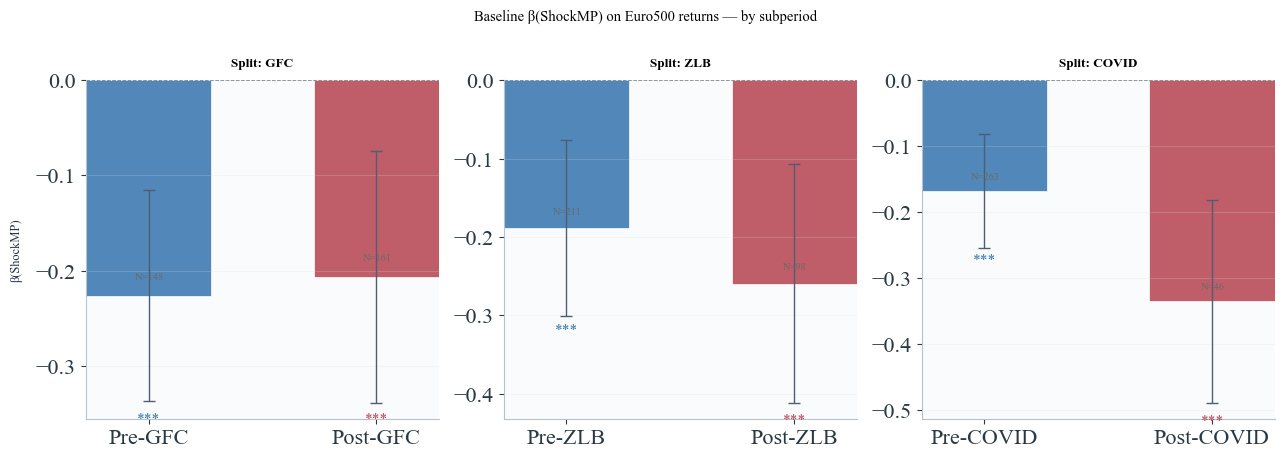

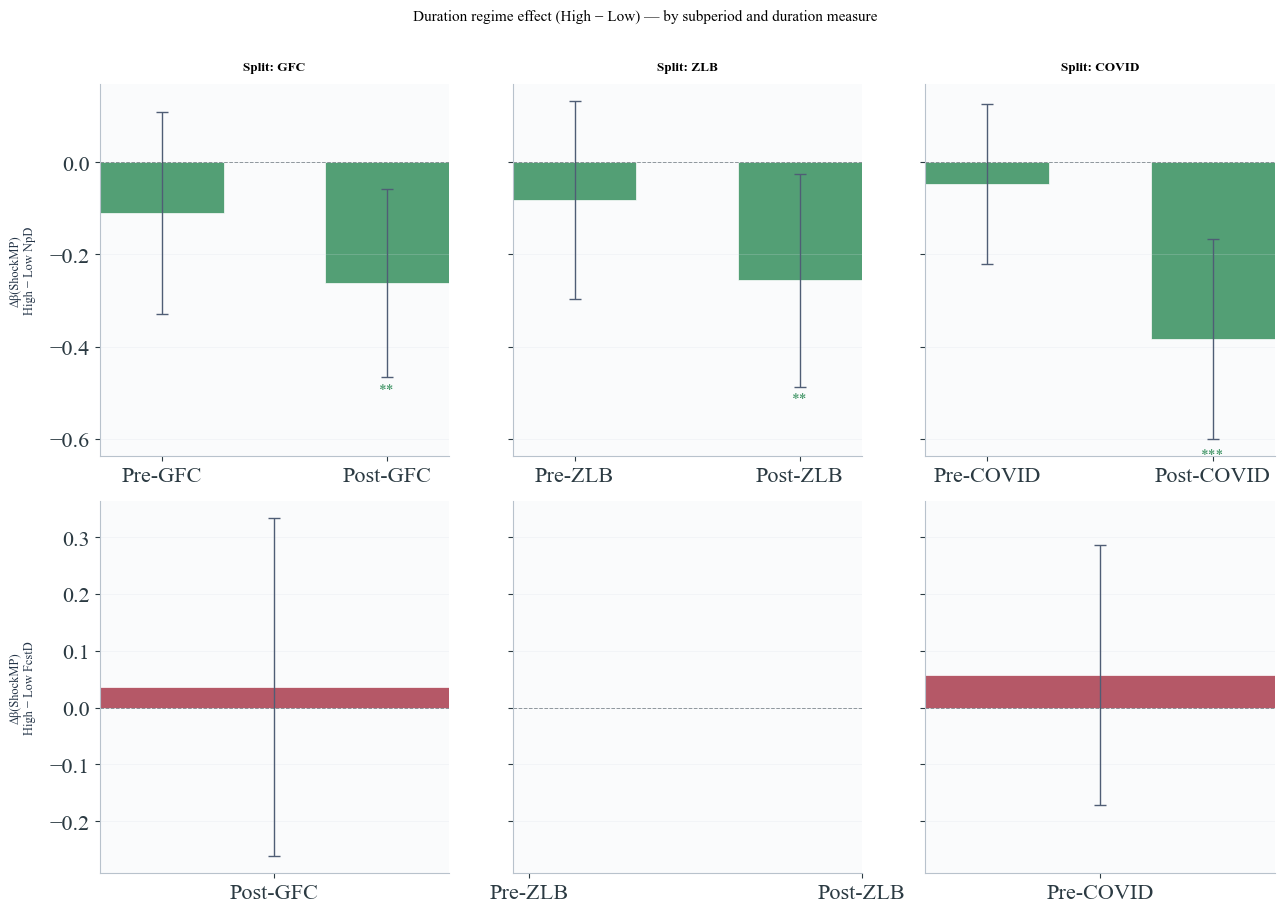

In [22]:
print("=" * 60)
print("EXTENSION A: SUBPERIOD ANALYSIS")
print("=" * 60)

# ---------------------------------------------------------------------------
# A1. Label subperiods
# ---------------------------------------------------------------------------
SUBPERIOD_CUTS = {
    "GFC":   pd.Timestamp("2008-09-15"),
    "ZLB":   pd.Timestamp("2014-01-01"),
    "COVID": pd.Timestamp("2020-03-01"),
}

def label_subperiods(df, cuts=SUBPERIOD_CUTS):
    out = df.copy()
    for name, cut in cuts.items():
        out[f"subperiod_{name}"] = np.where(
            out["event_date"] < cut, f"Pre-{name}", f"Post-{name}"
        )
    return out

analysis_sample       = label_subperiods(analysis_sample)
analysis_sample_fcstd = label_subperiods(analysis_sample_fcstd)


# ---------------------------------------------------------------------------
# A2. Baseline shock regression per subperiod half
# ---------------------------------------------------------------------------
def run_subperiod_baseline(df, split_col, y_col="R_0_1"):
    rows = []
    for period, part in df.groupby(split_col, sort=True):
        work = part.dropna(subset=["ShockMP", "ShockInfo", y_col]).copy()
        if len(work) < 10:
            continue
        X = sm.add_constant(work[["ShockMP", "ShockInfo"]], has_constant="add")
        res = sm.OLS(work[y_col].astype(float), X.astype(float)).fit(cov_type="HC1")
        rows.append({
            "split":           split_col.replace("subperiod_", ""),
            "period":          period,
            "N":               int(res.nobs),
            "coef(ShockMP)":   res.params.get("ShockMP",   np.nan),
            "se(ShockMP)":     res.bse.get("ShockMP",      np.nan),
            "t(ShockMP)":      res.tvalues.get("ShockMP",  np.nan),
            "p(ShockMP)":      res.pvalues.get("ShockMP",  np.nan),
            "coef(ShockInfo)": res.params.get("ShockInfo", np.nan),
            "se(ShockInfo)":   res.bse.get("ShockInfo",    np.nan),
            "t(ShockInfo)":    res.tvalues.get("ShockInfo",np.nan),
            "p(ShockInfo)":    res.pvalues.get("ShockInfo",np.nan),
            "R2":              res.rsquared,
        })
    return pd.DataFrame(rows)

subperiod_baseline_rows = [
    run_subperiod_baseline(analysis_sample, f"subperiod_{name}")
    for name in SUBPERIOD_CUTS
]
subperiod_baseline_table = pd.concat(subperiod_baseline_rows, ignore_index=True)

print("Baseline shock sensitivity by subperiod (R_0_1):")
display(subperiod_baseline_table)


# ---------------------------------------------------------------------------
# A3. Duration median regime split per subperiod half (NpD + FcstD)
# ---------------------------------------------------------------------------
def run_subperiod_regime(df, split_col,
                         duration_col="D_netpayout_monthly_event",
                         duration_label="NpD", y_col="R_0_1", min_obs=15):
    regime_rows, delta_rows = [], []
    for period, part in df.groupby(split_col, sort=True):
        sub = part.dropna(subset=[duration_col, "ShockMP", "ShockInfo", y_col]).copy()
        if len(sub) < min_obs * 2:
            continue
        med = sub[duration_col].median()
        sub["regime"] = np.where(sub[duration_col] >= med, "High", "Low")
        betas, ses = {}, {}
        for regime, chunk in sub.groupby("regime"):
            if len(chunk) < min_obs:
                continue
            X = sm.add_constant(chunk[["ShockMP", "ShockInfo"]], has_constant="add")
            res = sm.OLS(chunk[y_col].astype(float), X.astype(float)).fit(cov_type="HC1")
            betas[regime] = res.params
            ses[regime] = res.bse
            regime_rows.append({
                "split":          split_col.replace("subperiod_", ""),
                "period":         period,
                "duration":       duration_label,
                "regime":         regime,
                "N":              int(res.nobs),
                "coef(ShockMP)":  res.params.get("ShockMP", np.nan),
                "se(ShockMP)":    res.bse.get("ShockMP",    np.nan),
                "t(ShockMP)":     res.tvalues.get("ShockMP",np.nan),
                "p(ShockMP)":     res.pvalues.get("ShockMP",np.nan),
                "R2":             res.rsquared,
            })
        if "High" in betas and "Low" in betas:
            delta_mp = betas["High"].get("ShockMP", np.nan) - betas["Low"].get("ShockMP", np.nan)
            se_h = ses["High"].get("ShockMP", np.nan)
            se_l = ses["Low"].get("ShockMP", np.nan)
            se_delta = np.sqrt(se_h**2 + se_l**2) if not (np.isnan(se_h) or np.isnan(se_l)) else np.nan
            delta_rows.append({
                "split":       split_col.replace("subperiod_", ""),
                "period":      period,
                "duration":    duration_label,
                "Delta_MP":    delta_mp,
                "se_Delta_MP": se_delta,
            })
    return pd.DataFrame(regime_rows), pd.DataFrame(delta_rows)

# Run for NpD
all_regime, all_delta = [], []
for name in SUBPERIOD_CUTS:
    r, d = run_subperiod_regime(analysis_sample, f"subperiod_{name}",
                                duration_col="D_netpayout_monthly_event",
                                duration_label="NpD")
    all_regime.append(r)
    all_delta.append(d)

# Run for FcstD (on the FcstD subsample)
for name in SUBPERIOD_CUTS:
    r, d = run_subperiod_regime(analysis_sample_fcstd, f"subperiod_{name}",
                                duration_col="D_fcstd_monthly_event",
                                duration_label="FcstD")
    all_regime.append(r)
    all_delta.append(d)

subperiod_regime_table = pd.concat(all_regime, ignore_index=True)
subperiod_delta_table  = pd.concat(all_delta,  ignore_index=True)

print("\nDuration regime split by subperiod (NpD + FcstD):")
display(subperiod_regime_table)
print("\nHigh-minus-Low Δβ(ShockMP) by subperiod:")
display(subperiod_delta_table)

subperiod_baseline_table.to_csv(output_dir / "extension_a_subperiod_baseline.csv", index=False)
subperiod_regime_table.to_csv(output_dir / "extension_a_subperiod_regime.csv", index=False)
subperiod_delta_table.to_csv(output_dir / "extension_a_subperiod_delta.csv", index=False)


# ---------------------------------------------------------------------------
# A4. Plots
# ---------------------------------------------------------------------------
from scipy import stats as scipy_stats
set_global_plot_style()

PERIOD_ORDER = {
    "GFC":   ["Pre-GFC",   "Post-GFC"],
    "ZLB":   ["Pre-ZLB",   "Post-ZLB"],
    "COVID": ["Pre-COVID", "Post-COVID"],
}
_split_colors = [COLORS["blue"], COLORS["accent"]]

# Plot A1: baseline β(ShockMP) across subperiod halves
fig_a1, axes_a1 = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

for ax, split in zip(axes_a1, SUBPERIOD_CUTS):
    sub = (subperiod_baseline_table[subperiod_baseline_table["split"] == split]
           .set_index("period"))
    periods = PERIOD_ORDER[split]
    x = np.arange(len(periods))

    coefs = [float(sub.loc[p, "coef(ShockMP)"]) if p in sub.index else np.nan for p in periods]
    ses   = [float(sub.loc[p, "se(ShockMP)"])   if p in sub.index else np.nan for p in periods]
    pvals = [float(sub.loc[p, "p(ShockMP)"])    if p in sub.index else np.nan for p in periods]
    ns    = [int(sub.loc[p, "N"])               if p in sub.index else 0      for p in periods]

    errs = [1.96 * s if not np.isnan(s) else 0.0 for s in ses]

    ax.bar(x, coefs, width=0.55, color=_split_colors, alpha=0.82,
           edgecolor="white", linewidth=0.6,
           yerr=errs, capsize=4,
           error_kw={"ecolor": COLORS.get("neutral", "#aaa"), "linewidth": 1.0})
    ax.axhline(0, color=COLORS["reference"], linewidth=0.7, linestyle="--", alpha=0.5)

    for xi, (c, p, e, n) in enumerate(zip(coefs, pvals, errs, ns)):
        if not np.isnan(c):
            _star = significance_stars(p)
            if _star:
                _y_off = c + e + abs(c) * 0.05 if c >= 0 else c - e - abs(c) * 0.05
                ax.text(xi, _y_off, _star, ha="center",
                        va="bottom" if c >= 0 else "top",
                        fontsize=11, color=_split_colors[xi])
            ax.text(xi, c - 0.015 * np.sign(c) if c != 0 else -0.01, f"N={n}",
                    ha="center", va="top" if c >= 0 else "bottom",
                    fontsize=7.5, color="dimgray")

    ax.set_xticks(x)
    ax.set_xticklabels(periods, fontsize=8.5)
    ax.set_title(f"Split: {split}", fontsize=9.5, fontweight="bold")
    ax.set_ylabel("β(ShockMP)" if split == "GFC" else "", fontsize=9)
    style_axes(ax, grid_axis="y", grid_alpha=0.22)

fig_a1.suptitle("Baseline β(ShockMP) on Euro500 returns — by subperiod",
                fontsize=10.5, y=1.01)
fig_a1.tight_layout()
save_figure(fig_a1, "subperiod_baseline_shockmp", dpi=200)
plt.show()


# Plot A2: High-minus-Low Δβ(ShockMP) across subperiod halves (NpD + FcstD)
_dur_labels = ["NpD", "FcstD"]
_dur_available = [d for d in _dur_labels if d in subperiod_delta_table["duration"].values]
n_dur_rows = len(_dur_available)

fig_a2, axes_a2 = plt.subplots(n_dur_rows, 3, figsize=(12, 4),
                                sharey="row")
if n_dur_rows == 1:
    axes_a2 = axes_a2[np.newaxis, :]  # ensure 2D

for row_idx, dur_label in enumerate(_dur_available):
    dur_deltas = subperiod_delta_table[subperiod_delta_table["duration"] == dur_label]

    for col_idx, split in enumerate(SUBPERIOD_CUTS):
        ax = axes_a2[row_idx, col_idx]
        sub_d = dur_deltas[dur_deltas["split"] == split]
        periods = PERIOD_ORDER[split]
        deltas_plot, se_plot = [], []
        for p in periods:
            row = sub_d[sub_d["period"] == p]
            deltas_plot.append(float(row["Delta_MP"].iloc[0]) if not row.empty else np.nan)
            se_plot.append(float(row["se_Delta_MP"].iloc[0]) if not row.empty and "se_Delta_MP" in row.columns else np.nan)

        errs = [1.96 * s if not np.isnan(s) else 0.0 for s in se_plot]
        bar_colors = [COLORS.get("green", "#2ca02c") if not np.isnan(v) and v <= 0
                      else COLORS.get("red", "#d62728") for v in deltas_plot]

        x = np.arange(len(periods))
        ax.bar(x, deltas_plot, width=0.55, color=bar_colors, alpha=0.82,
               edgecolor="white", linewidth=0.6,
               yerr=errs, capsize=4,
               error_kw={"ecolor": COLORS.get("neutral", "#aaa"), "linewidth": 1.0})
        ax.axhline(0, color=COLORS["reference"], linewidth=0.7, linestyle="--", alpha=0.5)

        for xi, (v, se) in enumerate(zip(deltas_plot, se_plot)):
            if not np.isnan(v) and not np.isnan(se) and se > 0:
                _t = abs(v / se)
                _p = 2 * (1 - scipy_stats.norm.cdf(_t))
                _star = significance_stars(_p)
                if _star:
                    _e = 1.96 * se
                    _y_off = v + _e + abs(v) * 0.05 if v >= 0 else v - _e - abs(v) * 0.05
                    ax.text(xi, _y_off, _star, ha="center",
                            va="bottom" if v >= 0 else "top",
                            fontsize=11, color=bar_colors[xi])

        ax.set_xticks(x)
        ax.set_xticklabels(periods, fontsize=8.5)
        if row_idx == 0:
            ax.set_title(f"Split: {split}", fontsize=9.5, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(f"Δβ(ShockMP)\nHigh − Low {dur_label}", fontsize=9)
        style_axes(ax, grid_axis="y", grid_alpha=0.22)

fig_a2.suptitle("Duration regime effect (High − Low) — by subperiod and duration measure",
                fontsize=11, y=1.01)
fig_a2.tight_layout()
save_figure(fig_a2, "subperiod_regime_delta", dpi=200)
plt.show()

### Extension B: Sector-Level Duration Analysis

At the aggregate index level, duration heterogeneity is averaged away. We
partially recover cross-sectional variation by constructing sector-level
value-weighted duration series (NpD) and sector-level value-weighted returns,
then testing whether sectors with higher NpD react more strongly to ECB
monetary-policy shocks.

**Data:** firm-level daily returns from `euro500_daily_returns.parquet`, merged
with sector labels from `SECTOR_MAP`. Financials are excluded throughout.

**Specifications:**

1. **Pooled panel with sector + event FE** (OLS with dummies):
   R_{s,t} = α_s + α_t + β(ShockMP_t × D_{s,q(t)}) + γ(ShockInfo_t × D_{s,q(t)}) + ε

2. **Cross-sectional quartile spread**: for each event, compute
   avg(return | top-quartile NpD sectors) − avg(return | bottom-quartile NpD sectors),
   then regress this spread on ShockMP.

EXTENSION B: SECTOR-LEVEL DURATION ANALYSIS
Sector-duration panel: 714 sector x quarter obs
Sectors (10): ['Basic Materials', 'Consumer Cyclicals', 'Consumer Non-Cyclicals', 'Energy', 'Healthcare', 'Industrials', 'Institutions, Associations & Organizations', 'Real Estate', 'Technology', 'Utilities']

Sector x event dataset: 2,972 rows  (11 sectors, 312 events)
Merged sector panel: 2,000 usable sector x event obs

Sector-panel regression (NpD, sector + event FE, SE clustered by event):
  β(mp_x_sdur)   = -0.005003  SE = 0.006952  t = -0.720  p = 0.4718
  β(info_x_sdur) = 0.008340  SE = 0.009960  t = 0.837  p = 0.4024
  N = 2000,  R² = 0.7771

Quartile spread regression (top-NpD minus bottom-NpD sector returns):
  β(ShockMP)   = 0.0105  t = 0.427  p = 0.6696
  β(ShockInfo) = 0.0074  t = 0.299  p = 0.7649
  N = 149,  R² = 0.0027


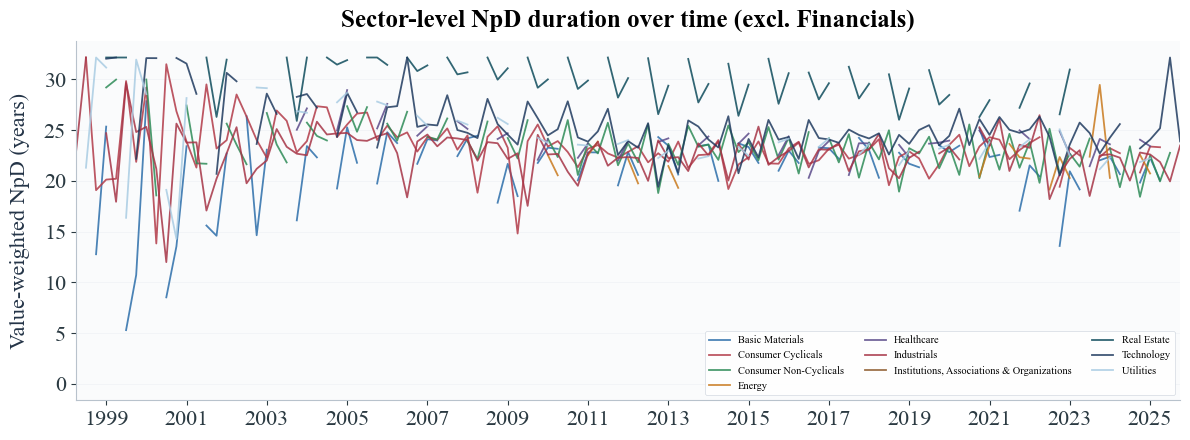

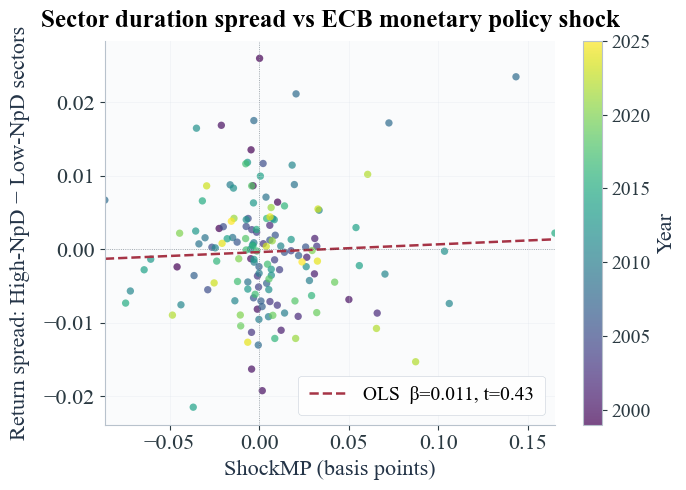

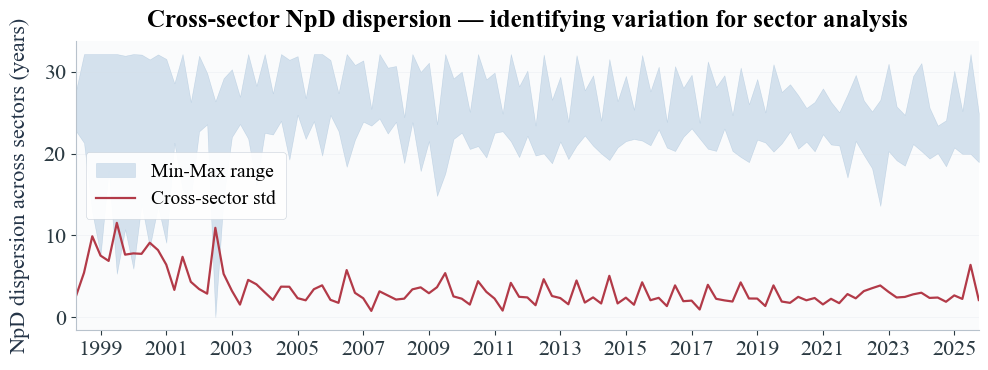

In [23]:
print("=" * 60)
print("EXTENSION B: SECTOR-LEVEL DURATION ANALYSIS")
print("=" * 60)

import statsmodels.formula.api as smf

path_euro500_daily = DATA_DIR / "euro500_daily_returns.parquet"

# ---------------------------------------------------------------------------
# B1. Sector-quarter value-weighted NpD
# ---------------------------------------------------------------------------
def build_sector_duration_panel(duration_df, exclude_fin=True):
    df = duration_df.copy()
    if "sector_name" not in df.columns:
        raise KeyError("No sector_name column found in duration_df.")
    df = df.dropna(subset=["sector_name"])
    df["sector"] = df["sector_name"].astype("string").str.strip()

    if exclude_fin:
        df = df[~df["sector"].str.casefold().str.contains("financial", na=False)].copy()

    valid = df.dropna(subset=["duration_value", "market_cap", "sector"]).copy()
    valid = valid[valid["market_cap"] > 0]

    def vw_mean(g):
        return np.average(g["duration_value"], weights=g["market_cap"])

    grouped = valid.groupby(["sector", "quarter_end"])
    panel = grouped.apply(vw_mean, include_groups=False).reset_index()
    panel.columns = ["sector", "quarter_end", "sector_duration_vw"]
    panel["sector_mcap"] = grouped["market_cap"].sum().values
    panel["sector_n_firms"] = grouped["firm_id"].nunique().values
    return panel.sort_values(["sector", "quarter_end"]).reset_index(drop=True)


sector_duration_panel = build_sector_duration_panel(netpayout_firm)
print(f"Sector-duration panel: {len(sector_duration_panel):,} sector x quarter obs")
print(f"Sectors ({sector_duration_panel['sector'].nunique()}): "
      f"{sorted(sector_duration_panel['sector'].unique())}")


# ---------------------------------------------------------------------------
# B2. Sector-level event returns from firm-level daily data
# ---------------------------------------------------------------------------
def build_sector_event_returns(path_daily, ecb_shocks_df, sector_map):
    raw = pd.read_parquet(path_daily)
    raw["date"] = pd.to_datetime(raw["date"])
    raw["firm_id"] = raw["firm_id"].astype("string")

    # Attach sector; drop Financials
    raw["sector"] = raw["firm_id"].map(sector_map)
    raw = raw.dropna(subset=["sector"])
    raw["sector"] = raw["sector"].astype("string").str.strip()
    raw = raw[~raw["sector"].str.casefold().str.contains("financial", na=False)]

    # Use mcap_eur for weighting
    mcap_col = "mcap_eur" if "mcap_eur" in raw.columns else None
    if mcap_col:
        raw["market_cap"] = pd.to_numeric(raw[mcap_col], errors="coerce")
    else:
        print("WARNING: no mcap column — using equal weights.")
        raw["market_cap"] = 1.0

    raw = raw.dropna(subset=["date", "ret", "market_cap"]).copy()
    raw = raw[raw["market_cap"] > 0].sort_values(["sector", "date"])

    # Value-weighted sector daily returns
    def vw_ret(g):
        return np.average(g["ret"], weights=g["market_cap"])

    sector_daily = (
        raw.groupby(["sector", "date"])
           .apply(vw_ret, include_groups=False)
           .reset_index(name="ret_vw")
           .sort_values(["sector", "date"])
    )

    # Forward-match to ECB event dates
    events = ecb_shocks_df[["event_date", "ShockMP", "ShockInfo"]].dropna().sort_values("event_date")

    rows = []
    for sector, grp in sector_daily.groupby("sector"):
        grp_s = grp.sort_values("date").reset_index(drop=True)
        dates_arr = grp_s["date"].values
        rets_arr = grp_s["ret_vw"].values

        for _, ev in events.iterrows():
            edate = ev["event_date"]
            idx = np.searchsorted(dates_arr, np.datetime64(edate))
            if idx >= len(dates_arr):
                continue
            r0 = rets_arr[idx]
            r1 = rets_arr[idx + 1] if idx + 1 < len(dates_arr) else np.nan
            r01 = (1 + r0) * (1 + r1) - 1 if not np.isnan(r1) else np.nan

            rows.append({
                "event_date":   edate,
                "trade_date":   pd.Timestamp(dates_arr[idx]),
                "sector":       sector,
                "R_0_sector":   r0,
                "R_0_1_sector": r01,
                "ShockMP":      ev["ShockMP"],
                "ShockInfo":    ev["ShockInfo"],
            })

    return pd.DataFrame(rows)


# ecb_shocks was loaded as ecb_shocks in Cell 9
sector_event_returns = build_sector_event_returns(
    path_euro500_daily, ecb_shocks, SECTOR_MAP
)
print(f"\nSector x event dataset: {len(sector_event_returns):,} rows  "
      f"({sector_event_returns['sector'].nunique()} sectors, "
      f"{sector_event_returns['event_date'].nunique()} events)")


# ---------------------------------------------------------------------------
# B3. Merge sector returns with sector duration
# ---------------------------------------------------------------------------
sector_event_returns["quarter_end"] = (
    sector_event_returns["trade_date"]
    .dt.to_period("Q")
    .dt.to_timestamp("Q")
)

sector_panel = sector_event_returns.merge(
    sector_duration_panel[["sector", "quarter_end",
                            "sector_duration_vw", "sector_n_firms"]],
    on=["sector", "quarter_end"],
    how="left",
)

# Cross-sectional z-score within each quarter
sector_panel["sector_duration_z"] = (
    sector_panel
    .groupby("quarter_end")["sector_duration_vw"]
    .transform(lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0.0)
)

sector_panel["mp_x_sdur"]   = sector_panel["ShockMP"]  * sector_panel["sector_duration_z"]
sector_panel["info_x_sdur"] = sector_panel["ShockInfo"] * sector_panel["sector_duration_z"]

n_usable = sector_panel.dropna(subset=["sector_duration_z", "R_0_1_sector"]).shape[0]
print(f"Merged sector panel: {n_usable:,} usable sector x event obs")


# ---------------------------------------------------------------------------
# B4. Spec 1 — Pooled panel with sector + event FE (via statsmodels dummies)
# ---------------------------------------------------------------------------
def run_sector_panel_fe(df, y_col="R_0_1_sector"):
    work = df.dropna(subset=[y_col, "sector_duration_z",
                              "ShockMP", "ShockInfo"]).copy()
    work["sector_cat"] = pd.Categorical(work["sector"])
    work["event_cat"] = pd.Categorical(work["event_date"])

    formula = f"{y_col} ~ mp_x_sdur + info_x_sdur + C(sector_cat) + C(event_cat)"
    res = smf.ols(formula, data=work).fit(cov_type="cluster",
                                           cov_kwds={"groups": pd.Categorical(work["event_date"]).codes})
    return res, work


sector_fe_res, sector_fe_work = run_sector_panel_fe(sector_panel)

print("\nSector-panel regression (NpD, sector + event FE, SE clustered by event):")
print(f"  β(mp_x_sdur)   = {sector_fe_res.params['mp_x_sdur']:.6f}  "
      f"SE = {sector_fe_res.bse['mp_x_sdur']:.6f}  "
      f"t = {sector_fe_res.tvalues['mp_x_sdur']:.3f}  "
      f"p = {sector_fe_res.pvalues['mp_x_sdur']:.4f}")
print(f"  β(info_x_sdur) = {sector_fe_res.params['info_x_sdur']:.6f}  "
      f"SE = {sector_fe_res.bse['info_x_sdur']:.6f}  "
      f"t = {sector_fe_res.tvalues['info_x_sdur']:.3f}  "
      f"p = {sector_fe_res.pvalues['info_x_sdur']:.4f}")
print(f"  N = {int(sector_fe_res.nobs)},  R² = {sector_fe_res.rsquared:.4f}")


# ---------------------------------------------------------------------------
# B5. Spec 2 — Cross-sectional quartile spread per event
# ---------------------------------------------------------------------------
def run_quartile_spread(df, duration_col="sector_duration_vw",
                        y_col="R_0_1_sector", q_lo=0.25, q_hi=0.75):
    rows = []
    for event_date, grp in df.groupby("event_date"):
        sub = grp.dropna(subset=[duration_col, y_col]).copy()
        if len(sub) < 6:
            continue
        lo = sub[duration_col].quantile(q_lo)
        hi = sub[duration_col].quantile(q_hi)
        top    = sub.loc[sub[duration_col] >= hi, y_col].mean()
        bottom = sub.loc[sub[duration_col] <= lo, y_col].mean()
        rows.append({
            "event_date":  event_date,
            "ShockMP":     grp["ShockMP"].iloc[0],
            "ShockInfo":   grp["ShockInfo"].iloc[0],
            "spread_ret":  top - bottom,
            "n_sectors":   len(sub),
        })
    return pd.DataFrame(rows)


quartile_spread = run_quartile_spread(sector_panel)

qs_work = quartile_spread.dropna(subset=["spread_ret", "ShockMP", "ShockInfo"]).copy()
X_qs = sm.add_constant(qs_work[["ShockMP", "ShockInfo"]], has_constant="add")
res_qs = sm.OLS(qs_work["spread_ret"].astype(float),
                X_qs.astype(float)).fit(cov_type="HC1")

print("\nQuartile spread regression (top-NpD minus bottom-NpD sector returns):")
print(f"  β(ShockMP)   = {res_qs.params['ShockMP']:.4f}  "
      f"t = {res_qs.tvalues['ShockMP']:.3f}  "
      f"p = {res_qs.pvalues['ShockMP']:.4f}")
print(f"  β(ShockInfo) = {res_qs.params['ShockInfo']:.4f}  "
      f"t = {res_qs.tvalues['ShockInfo']:.3f}  "
      f"p = {res_qs.pvalues['ShockInfo']:.4f}")
print(f"  N = {int(res_qs.nobs)},  R² = {res_qs.rsquared:.4f}")


# ---------------------------------------------------------------------------
# B6. Plots
# ---------------------------------------------------------------------------
set_global_plot_style()

_sector_palette = [
    COLORS["blue"], COLORS["accent"], COLORS["green"], COLORS["orange"],
    COLORS["purple"], COLORS["red"], COLORS["brown"], COLORS["primary"],
    COLORS["secondary"], COLORS["blue_light"],
]

# Plot B1: Sector NpD time series
sector_pivot = sector_duration_panel.pivot(
    index="quarter_end", columns="sector", values="sector_duration_vw"
)
fig_b1, ax_b1 = plt.subplots(figsize=(12, 4))
for i, col in enumerate(sorted(sector_pivot.columns)):
    ax_b1.plot(sector_pivot.index, sector_pivot[col],
               label=col, linewidth=1.3, alpha=0.85,
               color=_sector_palette[i % len(_sector_palette)])
ax_b1.set_xlabel("Quarter")
ax_b1.set_ylabel("Value-weighted NpD (years)")
ax_b1.set_title("Sector-level NpD duration over time (excl. Financials)")
style_axes(ax_b1, grid_axis="y", grid_alpha=0.22)
ax_b1.legend(loc="best", ncol=3, fontsize=7.5,
             frameon=True, facecolor=(1.0, 1.0, 1.0, 0.82),
             edgecolor="#C4CDD7", framealpha=0.92, fancybox=True)
style_time_axis(
    ax_b1,
    x_min=sector_pivot.index.min(),
    x_max=sector_pivot.index.max(),
    x_ticks=sector_pivot.index,
    date_fmt="%Y",
)
fig_b1.tight_layout()
save_figure(fig_b1, "sector_duration_timeseries", dpi=200)
plt.show()


# Plot B2: Scatter — quartile spread return vs ShockMP
fig_b2, ax_b2 = plt.subplots(figsize=(12, 4))
sc = ax_b2.scatter(
    qs_work["ShockMP"], qs_work["spread_ret"],
    c=qs_work["event_date"].dt.year,
    cmap="viridis", s=28, alpha=0.7, linewidths=0,
)
x_seq = np.linspace(qs_work["ShockMP"].min(), qs_work["ShockMP"].max(), 200)
x_fit_full = pd.DataFrame({"const": 1.0, "ShockMP": x_seq,
                            "ShockInfo": 0.0})[["const", "ShockMP", "ShockInfo"]]
ax_b2.plot(x_seq, res_qs.predict(x_fit_full),
           color=COLORS["red"], linewidth=1.8, linestyle="--",
           label=f"OLS  β={res_qs.params['ShockMP']:.3f}, "
                 f"t={res_qs.tvalues['ShockMP']:.2f}")
ax_b2.axhline(0, color=COLORS["reference"], linewidth=0.6, linestyle=":", alpha=0.5)
ax_b2.axvline(0, color=COLORS["reference"], linewidth=0.6, linestyle=":", alpha=0.5)
plt.colorbar(sc, ax=ax_b2, label="Year")
ax_b2.set_xlabel("ShockMP (basis points)")
ax_b2.set_ylabel("Return spread: High-NpD − Low-NpD sectors")
ax_b2.set_title("Sector duration spread vs ECB monetary policy shock")
style_axes(ax_b2, grid_axis="both", grid_alpha=0.22)
style_legend(ax_b2, loc="best")
fig_b2.tight_layout()
save_figure(fig_b2, "sector_quartile_spread_shockmp", dpi=200)
plt.show()


# Plot B3: NpD cross-sector dispersion over time
sector_dispersion = (
    sector_duration_panel
    .groupby("quarter_end")["sector_duration_vw"]
    .agg(["std", "min", "max"])
    .reset_index()
)
fig_b3, ax_b3 = plt.subplots(figsize=(12, 4))
ax_b3.fill_between(sector_dispersion["quarter_end"],
                   sector_dispersion["min"],
                   sector_dispersion["max"],
                   alpha=0.18, color=COLORS["blue"], label="Min-Max range")
ax_b3.plot(sector_dispersion["quarter_end"],
           sector_dispersion["std"],
           color=COLORS["accent"], linewidth=1.6, label="Cross-sector std")
ax_b3.set_xlabel("Quarter")
ax_b3.set_ylabel("NpD dispersion across sectors (years)")
ax_b3.set_title("Cross-sector NpD dispersion — identifying variation for sector analysis")
style_axes(ax_b3, grid_axis="y", grid_alpha=0.22)
style_legend(ax_b3, loc="best")
style_time_axis(
    ax_b3,
    x_min=sector_dispersion["quarter_end"].min(),
    x_max=sector_dispersion["quarter_end"].max(),
    x_ticks=sector_dispersion["quarter_end"],
    date_fmt="%Y",
)
fig_b3.tight_layout()
save_figure(fig_b3, "sector_duration_dispersion", dpi=200)
plt.show()

In [24]:
market_duration_monthly.to_csv(output_dir / "market_duration_monthly.csv", index=False)
event_dataset_monthly.to_csv(output_dir / "ecb_index_event_dataset_monthly.csv", index=False)
duration_variation_comparison.to_csv(output_dir / "market_duration_frequency_diagnostics.csv", index=False)
baseline_full_table.to_csv(output_dir / "index_regression_baseline_full_sample.csv", index=False)
baseline_large_shock_table.to_csv(output_dir / "index_regression_baseline_large_shocks.csv", index=False)
regime_results_full.to_csv(output_dir / "index_regression_regimes_full_sample.csv", index=False)
regime_differences_full.to_csv(output_dir / "index_regression_regime_deltas_full_sample.csv", index=False)
regime_results_large_shocks.to_csv(output_dir / "index_regression_regimes_large_shocks.csv", index=False)
regime_differences_large_shocks.to_csv(output_dir / "index_regression_regime_deltas_large_shocks.csv", index=False)

print("Saved additional monthly/regime outputs to the index_regressions output directory.")

Saved additional monthly/regime outputs to the index_regressions output directory.


## 13. Save outputs

The final section writes the key datasets and regression tables to disk so they can be reused in the thesis text, appendix tables, or later robustness work.


In [25]:
def diagnostic_summary_table(duration_df):
    summary = pd.DataFrame({
        "statistic": ["mean", "std", "min", "median", "max"],
        "market_duration_fcstd": [
            duration_df["market_duration_fcstd"].mean(),
            duration_df["market_duration_fcstd"].std(),
            duration_df["market_duration_fcstd"].min(),
            duration_df["market_duration_fcstd"].median(),
            duration_df["market_duration_fcstd"].max(),
        ],
        "market_duration_netpayout": [
            duration_df["market_duration_netpayout"].mean(),
            duration_df["market_duration_netpayout"].std(),
            duration_df["market_duration_netpayout"].min(),
            duration_df["market_duration_netpayout"].median(),
            duration_df["market_duration_netpayout"].max(),
        ],
    })
    return summary


duration_diagnostics = diagnostic_summary_table(market_duration_quarterly)
duration_correlation = market_duration_quarterly[["market_duration_fcstd", "market_duration_netpayout"]].corr()
avg_firms_coverage = pd.DataFrame({
    "metric": [
        "Average firms (FcstD)",
        "Average firms (Net-Payout)",
        "Average coverage (FcstD)",
        "Average coverage (Net-Payout)",
        "First quarter (FcstD)",
        "Last quarter (FcstD)",
    ],
    "value": [
        market_duration_quarterly["n_firms_fcstd"].mean(),
        market_duration_quarterly["n_firms_netpayout"].mean(),
        market_duration_quarterly["coverage_fcstd"].mean(),
        market_duration_quarterly["coverage_netpayout"].mean(),
        str(market_duration_quarterly.loc[market_duration_quarterly["market_duration_fcstd"].notna(), "quarter_end"].min()),
        str(market_duration_quarterly.loc[market_duration_quarterly["market_duration_fcstd"].notna(), "quarter_end"].max()),
    ],
})

top_high_quarters = market_duration_quarterly[["quarter_end", "market_duration_fcstd", "market_duration_netpayout"]].sort_values("market_duration_fcstd", ascending=False).head(10)
top_low_quarters = market_duration_quarterly[["quarter_end", "market_duration_fcstd", "market_duration_netpayout"]].sort_values("market_duration_fcstd", ascending=True).head(10)

print("Summary stats: market duration")
display(duration_diagnostics)
print("Correlation between duration concepts")
display(duration_correlation)
print("Average number of firms and coverage")
display(avg_firms_coverage)
print("Top 10 highest-duration quarters")
display(top_high_quarters)
print("Top 10 lowest-duration quarters")
display(top_low_quarters)

market_duration_quarterly.to_csv(output_dir / "market_duration_quarterly.csv", index=False)
event_dataset.to_csv(output_dir / "ecb_index_event_dataset.csv", index=False)
results_export = pd.concat([
    results_main.assign(result_set="main"),
    results_raw_duration.assign(result_set="raw_duration"),
    results_large_shocks.assign(result_set="large_shocks"),
    results_hac.assign(result_set="hac"),
], ignore_index=True)
results_export.to_csv(output_dir / "index_regression_results_main.csv", index=False)
TABLE_3.to_csv(output_dir / "index_regression_results_reader.csv", index=False)
TABLE_1.to_latex(output_dir / "index_regression_results_main.tex", index=False, float_format="%.4f")

print(f"Saved outputs to: {output_dir.resolve()}")

Summary stats: market duration


,statistic,market_duration_fcstd,market_duration_netpayout
0,mean,4.181893,23.957656
1,std,0.252978,2.231768
2,min,3.814215,15.318002
3,median,4.092769,23.769858
4,max,4.644967,30.507145


Correlation between duration concepts


,market_duration_fcstd,market_duration_netpayout
market_duration_fcstd,1.000000,0.495745
market_duration_netpayout,0.495745,1.000000


Average number of firms and coverage


...

Top 10 highest-duration quarters


,quarter_end,market_duration_fcstd,market_duration_netpayout
27,2003-12-31,4.644967,25.612794
31,2004-12-31,4.592410,27.088670
47,2008-12-31,4.559462,23.734276
59,2011-12-31,4.519483,23.288908
55,2010-12-31,4.412737,23.325558
51,2009-12-31,4.361654,23.643493
35,2005-12-31,4.347943,26.217721
43,2007-12-31,4.289110,24.644979
39,2006-12-31,4.283287,24.887518
63,2012-12-31,4.191580,22.952619


Top 10 lowest-duration quarters


,quarter_end,market_duration_fcstd,market_duration_netpayout
95,2020-12-31,3.814215,23.994022
83,2017-12-31,3.882771,23.673500
99,2021-12-31,3.887154,23.942742
91,2019-12-31,3.935774,23.751662
111,2024-12-31,3.955353,23.143337
107,2023-12-31,3.975782,23.204541
79,2016-12-31,3.981620,23.820577
75,2015-12-31,4.015263,23.902665
67,2013-12-31,4.080928,23.146187
103,2022-12-31,4.084614,22.768079


Saved outputs to: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/index_regressions
